# Predicting NYC Housing Prices

## Goal of the Project
The goal of this project is to **predict housing prices in New York City** using a dataset that includes features such as property type, neighborhood, number of bedrooms, number of bathrooms, and area. By building a robust regression model, we aim to:

1. **Understand the key factors** that influence housing prices in NYC.
2. **Provide accurate price predictions** that can assist buyers, sellers, and real estate professionals in making informed decisions.
3. **Explore and visualize trends** in the housing market, such as the impact of location, property size, and type on pricing.

This project will involve:
- **Exploratory Data Analysis (EDA)** to uncover patterns and relationships in the data.
- **Feature Engineering** to create meaningful predictors from the raw data.
- **Model Development** using machine learning algorithms to predict housing prices.
- **Evaluation** of model performance using metrics like RMSE and R².


# Load, clean and first look the data

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import probplot

In [4]:
import geopandas as gpd

In [5]:
# Import dataset
file = '../data/NY-House-Dataset.csv'

In [6]:
# load the data
df = pd.read_csv(file)

In [7]:
# Inspect the data
df.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


In [8]:
# Check the dataset's structure
print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")
print("\nColumn names and data types:")
print(df.info())

Number of rows: 4801, Number of columns: 17

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4801 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4801 non-null   object 
 1   TYPE                         4801 non-null   object 
 2   PRICE                        4801 non-null   int64  
 3   BEDS                         4801 non-null   int64  
 4   BATH                         4801 non-null   float64
 5   PROPERTYSQFT                 4801 non-null   float64
 6   ADDRESS                      4801 non-null   object 
 7   STATE                        4801 non-null   object 
 8   MAIN_ADDRESS                 4801 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4801 non-null   object 
 10  LOCALITY                     4801 non-null   object 
 11  SUBLOCALITY                  4801 non-null   object 
 12  ST

First Look Observations:
1. BROKERTITLE - Appears to just contain broker names (likely not useful for analysis)
2. BEDS (int) vs BATHS (float) - different data types
3. Address fields - Multiple address columns with potential redundancy:
   - ADDRESS, MAIN_ADDRESS, FORMATTED_ADDRESS all seem similar.
4. STATE - actually contains ZIP codes
5. Administrative geography fields - Inconsistent granularity:
   - ADMINISTRATIVE_AREA_LEVEL_2 mixes counties with country
   - STREET_NAME contains both street names and area names
   - SUBLOCALITY seems most promising for neighborhood analysis


- Consider creating 'NEIGHBORHOOD' and 'BOROUGH'/'COUNTY' feature
- Address fields could be helpfull if geocoding will be needed

In [9]:
# Inspect numerative features
df.describe()

,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE
count,4.801000e+03,4801.000000,4801.000000,4801.000000,4801.000000,4801.000000
mean,2.356940e+06,3.356801,2.373861,2184.207862,40.714227,-73.941601
std,3.135525e+07,2.602315,1.946962,2377.140894,0.087676,0.101082
min,2.494000e+03,1.000000,0.000000,230.000000,40.499546,-74.253033
25%,4.990000e+05,2.000000,1.000000,1200.000000,40.639375,-73.987143
50%,8.250000e+05,3.000000,2.000000,2184.207862,40.726749,-73.949189
75%,1.495000e+06,4.000000,3.000000,2184.207862,40.771923,-73.870638
max,2.147484e+09,50.000000,50.000000,65535.000000,40.912729,-73.702450


Right-skewness evident from:

Price: Median 2,147,484,000<br>
Beds: Median 3 vs Max 50<br>
Bath: Median 2 vs Max 50<br>
Sqft: Median 2184.2 vs Max 65535.0<br>

Option 1: Apply log transformation<br>
Option 2: Analyze luxury segment separately<br>
Option 3: Winsorize extreme values<br>
<br>
Suspicious pattern detected in PROPERTYSQFT:

Exact same value (2184.21) appears as:
Mean, 50th percentile (median), 75th percentile<br>
This suggests: Missing values may have been imputed with this number

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4801 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4801 non-null   object 
 1   TYPE                         4801 non-null   object 
 2   PRICE                        4801 non-null   int64  
 3   BEDS                         4801 non-null   int64  
 4   BATH                         4801 non-null   float64
 5   PROPERTYSQFT                 4801 non-null   float64
 6   ADDRESS                      4801 non-null   object 
 7   STATE                        4801 non-null   object 
 8   MAIN_ADDRESS                 4801 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4801 non-null   object 
 10  LOCALITY                     4801 non-null   object 
 11  SUBLOCALITY                  4801 non-null   object 
 12  STREET_NAME                  4801 non-null   object 
 13  LONG_NAME         

In [11]:
# Check for Nulls
df.isna().sum()

BROKERTITLE                    0
TYPE                           0
PRICE                          0
BEDS                           0
BATH                           0
PROPERTYSQFT                   0
ADDRESS                        0
STATE                          0
MAIN_ADDRESS                   0
ADMINISTRATIVE_AREA_LEVEL_2    0
LOCALITY                       0
SUBLOCALITY                    0
STREET_NAME                    0
LONG_NAME                      0
FORMATTED_ADDRESS              0
LATITUDE                       0
LONGITUDE                      0
dtype: int64

No null data

In [12]:
# Check for duplicates
df.duplicated().sum()

np.int64(214)

In [13]:
# Drop duplicates
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
# Standartize column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [16]:
df.columns

Index(['brokertitle', 'type', 'price', 'beds', 'bath', 'propertysqft',
       'address', 'state', 'main_address', 'administrative_area_level_2',
       'locality', 'sublocality', 'street_name', 'long_name',
       'formatted_address', 'latitude', 'longitude'],
      dtype='object')

In [17]:
df.bath = df.bath.astype(int)

In [18]:
original_length = df.shape[0]

In [19]:
original_length

4587

## Exploratory Data Analysis (EDA)

## Price distribution analysis

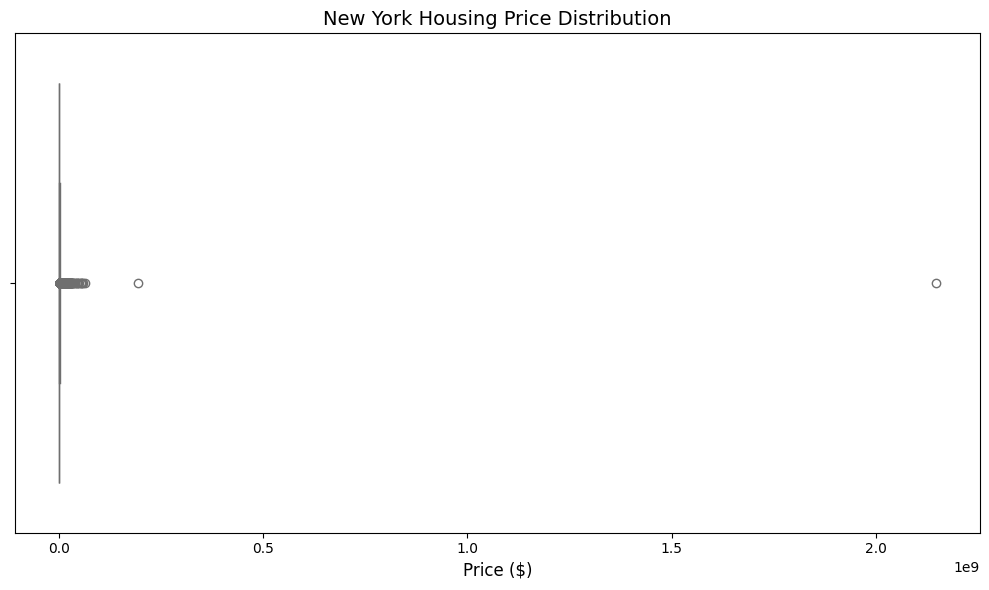

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df.price, color='skyblue')

# Add informative titles and labels
plt.title('New York Housing Price Distribution', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.tight_layout()

# Display plot
plt.show()

In [21]:
# Right-skewed price distribution. Should check for error data

In [22]:
df.sort_values(by=['price'], ascending=False).head()

,brokertitle,type,price,beds,bath,propertysqft,address,state,main_address,administrative_area_level_2,locality,sublocality,street_name,long_name,formatted_address,latitude,longitude
304,Brokered by ANNE LOPA REAL ESTATE,House for sale,2147483647,7,6,10000.000000,6659-6675 Amboy Rd,"New York, NY 10309","6659-6675 Amboy RdNew York, NY 10309",United States,New York,Richmond County,Staten Island,Amboy Road,"6659 Amboy Rd, Staten Island, NY 10309, USA",40.518484,-74.224418
1,Brokered by Serhant,Condo for sale,195000000,7,10,17545.000000,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
69,Brokered by Sotheby's International Realty - E...,Townhouse for sale,65000000,3,2,15200.000000,4 E 79th St,"New York, NY 10075","4 E 79th StNew York, NY 10075",United States,New York,New York County,New York,East 79th Street,"4 E 79th St, New York, NY 10075, USA",40.776561,-73.963317
1075,Brokered by COMPASS,Co-op for sale,60000000,8,8,2184.207862,960 5th Ave Unit 12,"Manhattan, NY 10075","960 5th Ave Unit 12Manhattan, NY 10075",New York,New York County,New York,Manhattan,960,"960 5th Ave #12, New York, NY 10075, USA",40.775642,-73.964247
141,Brokered by Douglas Elliman - 575 Madison Ave,House for sale,56000000,11,10,24000.000000,9 W 54th St,"New York, NY 10019","9 W 54th StNew York, NY 10019",United States,New York,New York County,New York,West 54th Street,"9 W 54th St, New York, NY 10019, USA",40.761600,-73.976191


In [23]:
# 2147483647 is error input, should be dropped

In [24]:
df = df[df.price < df.price.max()]

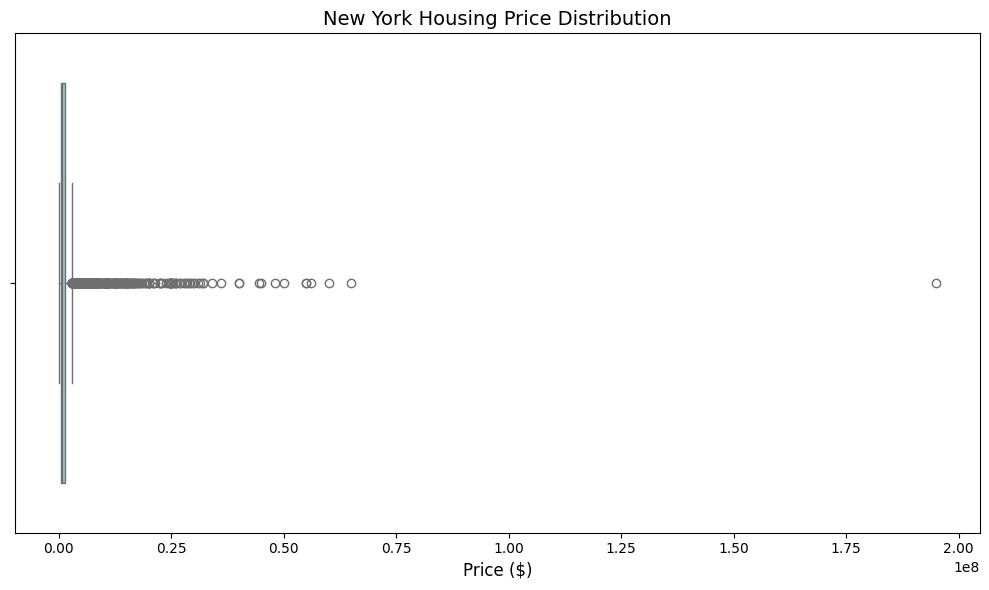

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df.price, color='skyblue')

# Add informative titles and labels
plt.title('New York Housing Price Distribution', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.tight_layout()

# Display plot
plt.show()

In [26]:
# Still hava an outlier on 195000000$.I checked this property, apparently it is a very famous ultra expensive apartment.
# I will also exclude it

In [27]:
df = df[df.price < df.price.max()]

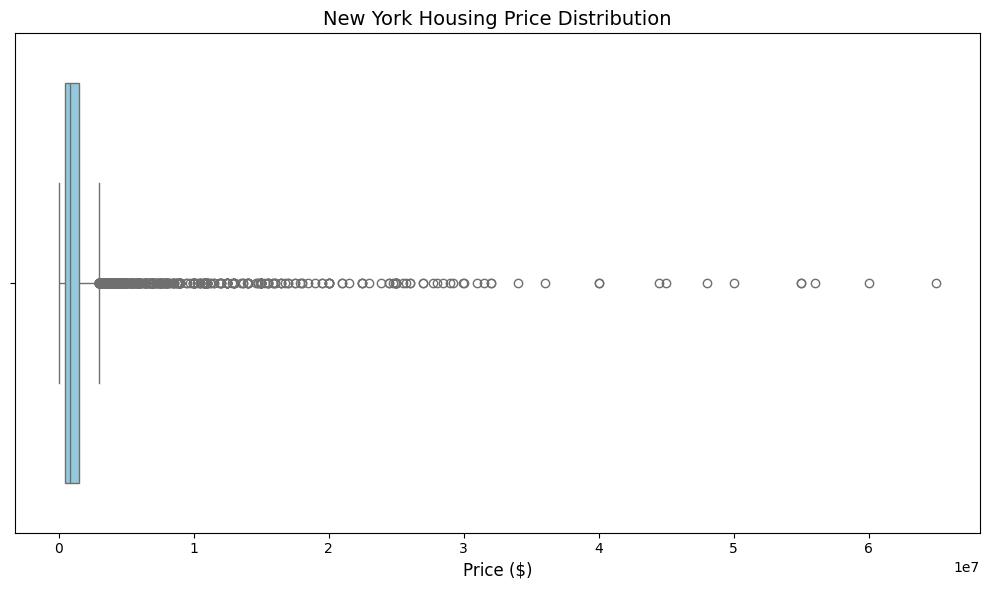

In [28]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df.price, color='skyblue')

# Add informative titles and labels
plt.title('New York Housing Price Distribution', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.tight_layout()

# Display plot
plt.show()

In [29]:
# Now boxplot looks reasonable

<Axes: xlabel='price', ylabel='type'>

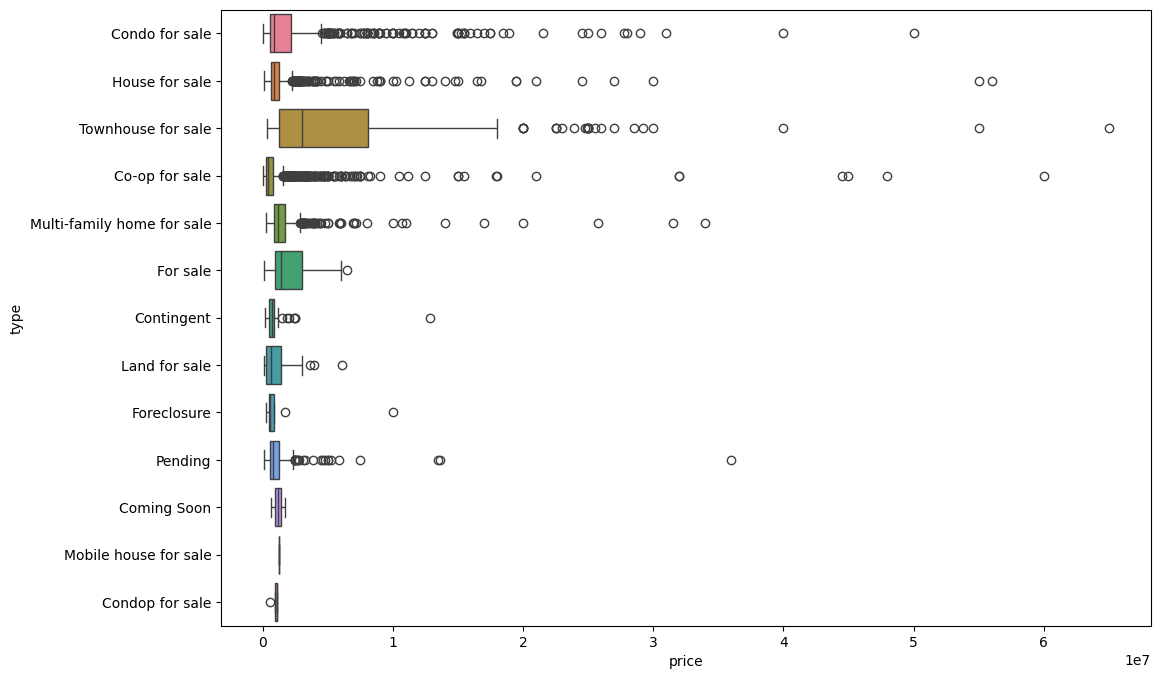

In [190]:
# Create price distribution visualization by property type
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='price', y='type', hue='type')

In [31]:
# Here we can see that we have a stratification of the market, apparently townhouses are considered more as luxurious property

In [32]:
# Calculate 90th percentile price thresholds by property type to identify price ceilings 
# for the top 10% of each property type and understand price distribution characteristics across categories

type_thresholds = df.groupby('type')['price'].quantile(0.9) 

In [33]:
print('0.90 quantile by type of houses')
print(type_thresholds.sort_values())
print('mean:',type_thresholds.mean())
print('median:',type_thresholds.median())

0.90 quantile by type of houses
type
Condop for sale                1111500.0
Contingent                     1119400.0
Mobile house for sale          1288000.0
Foreclosure                    1494900.0
Coming Soon                    1590400.0
Co-op for sale                 2150000.0
Pending                        2290400.0
House for sale                 2399600.0
Multi-family home for sale     2499000.0
Land for sale                  2729980.0
For sale                       4199900.0
Condo for sale                 5250000.0
Townhouse for sale            15892000.0
Name: price, dtype: float64
mean: 3385775.384615385
median: 2290400.0


In [34]:
# We again observe that the townhouse category is significantly different

In [35]:
# Calculate 50th percentile price thresholds by property type to assess entry - middle division point

type_thresholds_50 = df.groupby('type')['price'].quantile(0.5)
print('0.50 quantile by type of houses')
print(type_thresholds_50.sort_values())
print('mean:',type_thresholds_50.mean())
print('median:',type_thresholds_50.median())

0.50 quantile by type of houses
type
Co-op for sale                 425000.0
Foreclosure                    592450.0
Land for sale                  675000.0
Contingent                     689900.0
Pending                        825000.0
House for sale                 858000.0
Condo for sale                 880000.0
For sale                      1044500.0
Condop for sale               1072500.0
Coming Soon                   1172000.0
Multi-family home for sale    1199000.0
Mobile house for sale         1288000.0
Townhouse for sale            2995000.0
Name: price, dtype: float64
mean: 1055103.8461538462
median: 880000.0


In [36]:
# Threshold set at $3,000,000 based on central tendency analysis of the 0.90 quantile prices by property type
# And for entry - middle division set at $1,000,000
# Probable downside is that townhouses could be undervalued by modelling

# Create the upper segment flag
df['is_upper'] = (df['price'] > 3_000_000).astype(int)

# Also add middle segment more then 1 mln and lower then upper segment
df['is_mid'] = ((df['price'] > 1_000_000) & (df['price'] <= 3_000_000)).astype(int)

# Also create cateforical price segment column
df['price_segment'] = pd.cut(
    df['price'],
    bins=[0, 1_000_000, 3_000_000, np.inf],
    labels=['entry', 'mid', 'upper'],
    include_lowest=True,
    right=True
)

In [37]:
# Apply natural log transformation to price
df['log_price'] = np.log(df.price)

<Axes: xlabel='log_price', ylabel='type'>

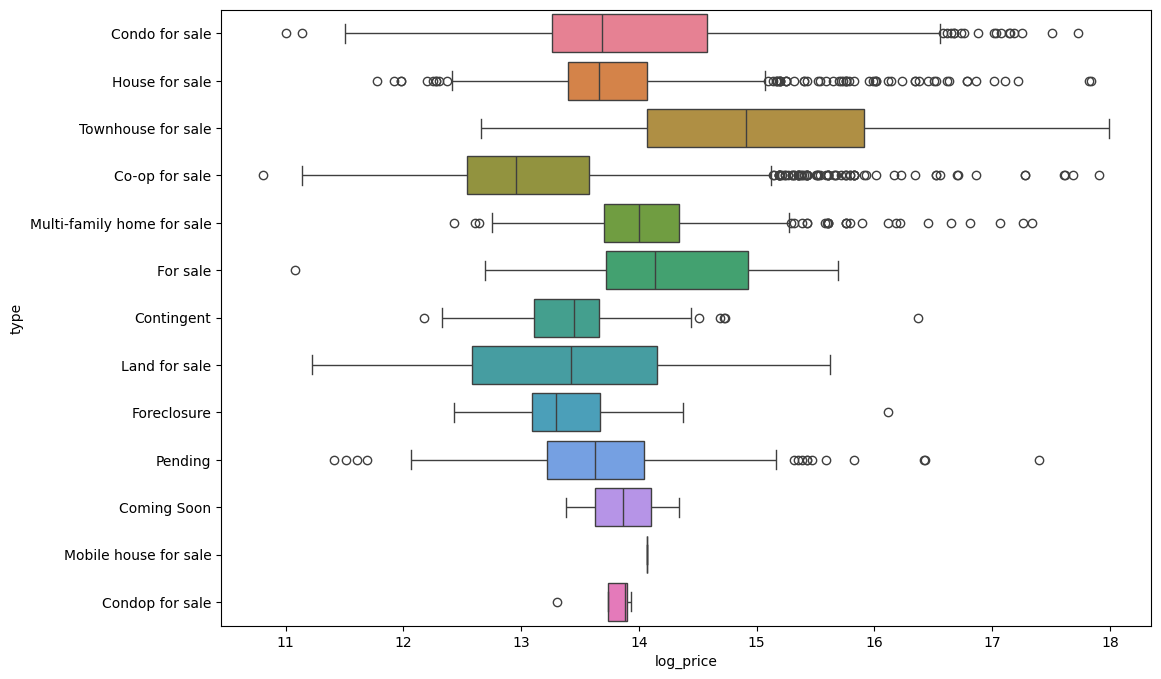

In [191]:
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='log_price', y='type', hue='type')

<Axes: xlabel='log_price', ylabel='Count'>

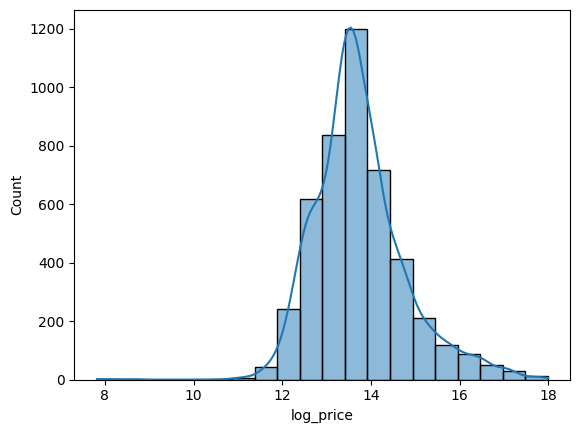

In [39]:
sns.histplot(df.log_price, bins=20, kde=True)

In [40]:
# log_price looks quite normal

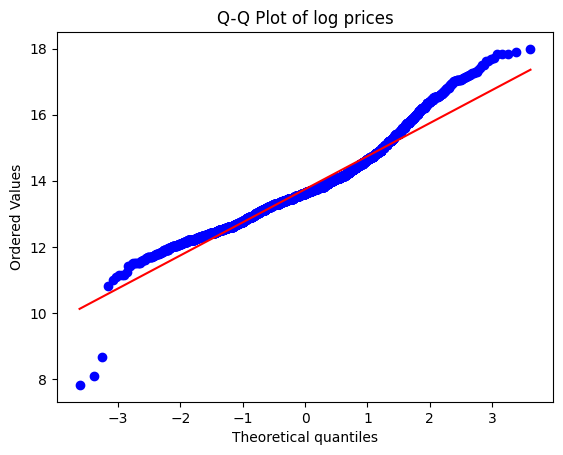

In [41]:
# Identify outliers on Q-Q plot
probplot(df['log_price'], dist="norm", plot=plt)
plt.title("Q-Q Plot of log prices")
plt.show()

In [42]:
# I see three outliers in lower range

In [43]:
df.sort_values('price').head()

,brokertitle,type,price,beds,bath,propertysqft,address,state,main_address,administrative_area_level_2,...,sublocality,street_name,long_name,formatted_address,latitude,longitude,is_upper,is_mid,price_segment,log_price
317,Brokered by Living NY - Main Office,For sale,2494,2,1,2184.207862,635 W 170th St Apt 4F,"New York, NY 10032","635 W 170th St Apt 4FNew York, NY 10032",New York,...,New York,Manhattan,635,"635 W 170th St #4f, New York, NY 10032, USA",40.843406,-73.940795,0,0,entry,7.821643
310,Brokered by Living NY - Main Office,For sale,3225,3,1,2184.207862,635 W 170th St Apt 2C,"New York, NY 10032","635 W 170th St Apt 2CNew York, NY 10032",New York,...,New York,Manhattan,635,"635 W 170th St #2c, New York, NY 10032, USA",40.843406,-73.940795,0,0,entry,8.078688
360,Brokered by Century 21 Realty First,Land for sale,5800,3,2,2184.207862,4515 Avenue N Lot 5,"Brooklyn, NY 11234","4515 Avenue N Lot 5Brooklyn, NY 11234",New York,...,Brooklyn,Flatlands,4515,"4515 Avenue N #5, Brooklyn, NY 11234, USA",40.618915,-73.931211,0,0,entry,8.665613
463,Brokered by Morris Park Realty Group,Co-op for sale,49500,3,2,800.000000,150 City Island Ave Unit E3,"Bronx, NY 10464","150 City Island Ave Unit E3Bronx, NY 10464",New York,...,The Bronx,City Island,150,"150 City Island Ave #3e, Bronx, NY 10464, USA",40.843284,-73.784603,0,0,entry,10.809728
979,Brokered by COMPASS,Condo for sale,60000,3,1,445.000000,2 E 55th St Unit 809W35,"Manhattan, NY 10022","2 E 55th St Unit 809W35Manhattan, NY 10022",New York,...,New York,Manhattan,2,"2 E 55th St 809 35, New York, NY 10022, USA",40.761398,-73.974613,0,0,entry,11.002100


In [44]:
# Data cleaning:
# - $2,494 and $3,225 (Manhattan apartments) - Below realistic thresholds
# - $5,800 (land) - Far below NYC market minimums

df = df[df.price>10000]

In [45]:
# Reset index after cleaning
df = df.reset_index(drop=True)

In [46]:
1 - len(df)/original_length

0.0010900370612600963

In [47]:
# dropped only 0.1% of data

## Other variables distribution

In [48]:
df.columns

Index(['brokertitle', 'type', 'price', 'beds', 'bath', 'propertysqft',
       'address', 'state', 'main_address', 'administrative_area_level_2',
       'locality', 'sublocality', 'street_name', 'long_name',
       'formatted_address', 'latitude', 'longitude', 'is_upper', 'is_mid',
       'price_segment', 'log_price'],
      dtype='object')

### _Brokertitle_

In [49]:
df.brokertitle.value_counts()

brokertitle
Brokered by COMPASS                              435
Brokered by Douglas Elliman - 575 Madison Ave    109
Brokered by Brown Harris Stevens                  93
Brokered by Corcoran East Side                    86
Brokered by RE MAX Edge                           75
                                                ... 
Brokered by Tworealestate Llc                      1
Brokered by Blue Key Real Estate Brokerage         1
Brokered by Douglas Elliman - New Hyde Park        1
Brokered by Renken Realty LLC                      1
Brokered by Contact Realty Ii Corp                 1
Name: count, Length: 1035, dtype: int64

In [50]:
df.brokertitle.value_counts().describe()

count    1035.000000
mean        4.427053
std        15.918532
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max       435.000000
Name: count, dtype: float64

In [51]:
# High cardinality variable, it looks like it's not going to be helpfull

In [52]:
# Drop brokertitle due to high cardinality (1035 brokers, median=1)
df.drop(columns=['brokertitle'], inplace=True)

### _Type_

In [53]:
df.type.value_counts()

type
Co-op for sale                1388
House for sale                 965
Condo for sale                 841
Multi-family home for sale     699
Townhouse for sale             288
Pending                        229
Contingent                      87
Land for sale                   46
For sale                        18
Foreclosure                     14
Condop for sale                  4
Coming Soon                      2
Mobile house for sale            1
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='type'>

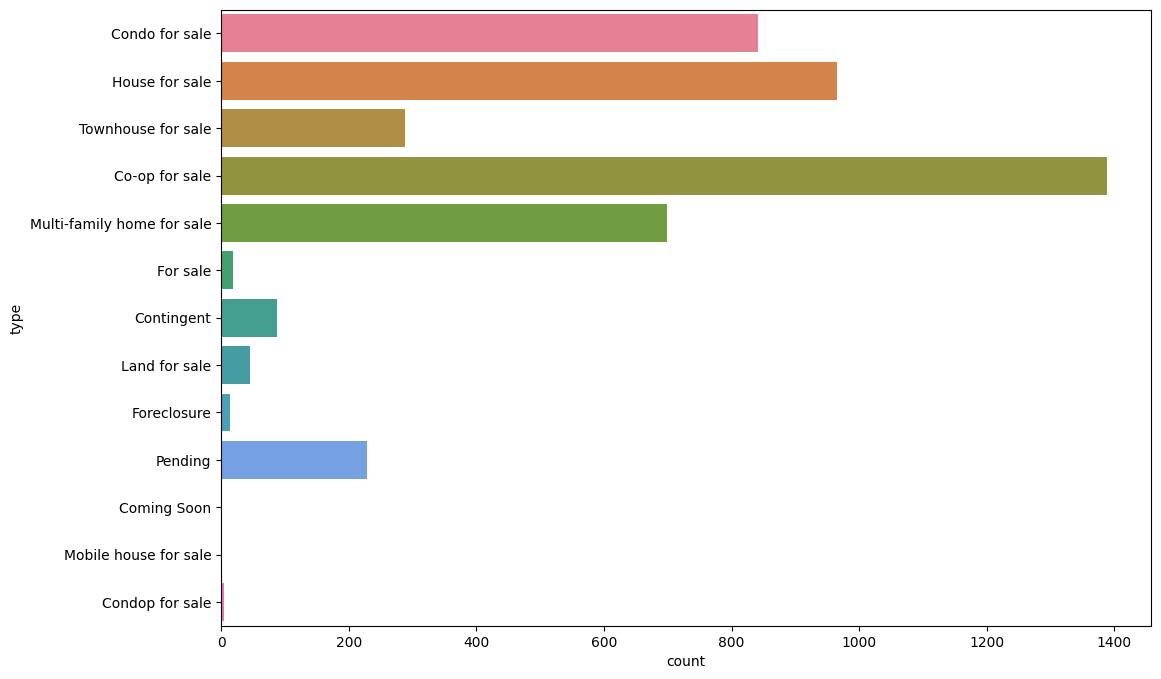

In [192]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='type', hue='type')

In [55]:
# Identify types to potentially consolidate
rare_types = df['type'].value_counts()[df['type'].value_counts() < 20].index
print(f"Rare types (<20 listings): {list(rare_types)}")

Rare types (<20 listings): ['For sale', 'Foreclosure', 'Condop for sale', 'Coming Soon', 'Mobile house for sale']


In [56]:
# Group rare types in other category
df['type_clean'] = np.where(df['type'].isin(rare_types), 'Other', df['type'])

In [57]:
# Averages by type
df.groupby('type_clean')[['price', 'beds', 'bath', 'propertysqft', ]].mean().sort_values('price', ascending=False)

,price,beds,bath,propertysqft
type_clean,,,,
Townhouse for sale,6.406234e+06,5.020833,3.805556,3887.512776
Condo for sale,2.387024e+06,2.322235,1.985731,1552.737999
Other,1.676593e+06,3.589744,2.333333,2203.941082
Multi-family home for sale,1.666781e+06,6.261803,3.907010,3210.209600
House for sale,1.565096e+06,3.730570,2.495337,2246.429021
Pending,1.362436e+06,3.179039,2.218341,2076.871914
Land for sale,1.128747e+06,3.000000,2.000000,2157.377256
Co-op for sale,1.113426e+06,1.984870,1.436599,1658.496424
Contingent,8.886932e+05,3.218391,2.172414,1782.559344


In [58]:
# Here we also can see that townhouse type differs from others

<Axes: xlabel='price', ylabel='type_clean'>

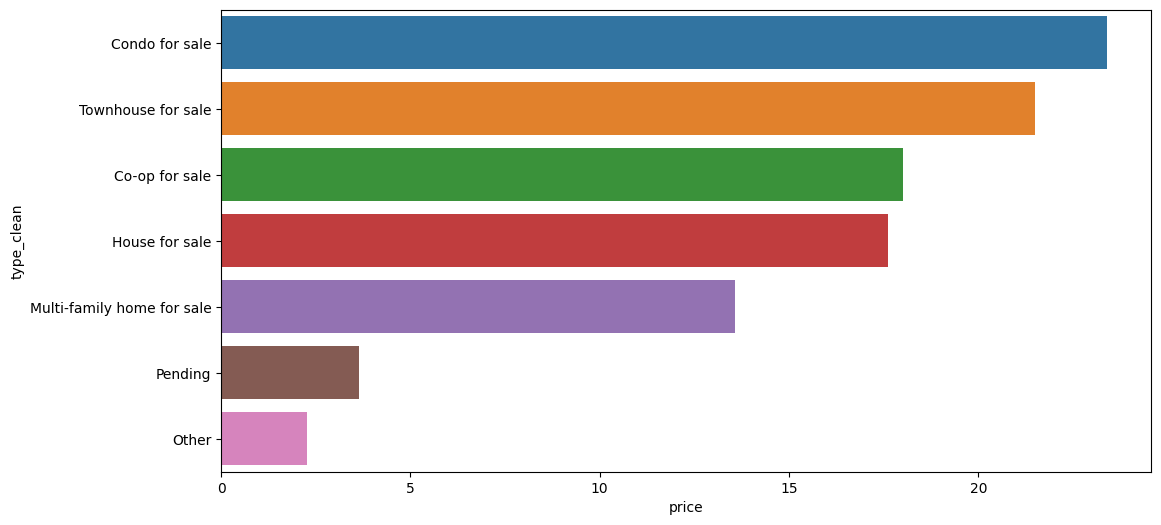

In [193]:
# Calculate market share by types
market_share = (df.groupby('type_clean')['price'].sum() / df.price.sum() * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            x='price',
            y='type_clean',
            hue='type_clean')

In [60]:
market_share

type_clean
Condo for sale                23.397448
Townhouse for sale            21.503595
Co-op for sale                18.012197
House for sale                17.602897
Multi-family home for sale    13.579116
Pending                        3.636364
Contingent                     0.901129
Other                          0.762093
Land for sale                  0.605160
Name: price, dtype: float64

In [61]:
# Additionally consolidate rare property types (<1% market share) into 'Other' category
df['type_clean'] = np.where(df['type_clean'].isin(market_share[market_share < 1.0].index),'Other', df['type_clean'])

<Axes: xlabel='price', ylabel='type_clean'>

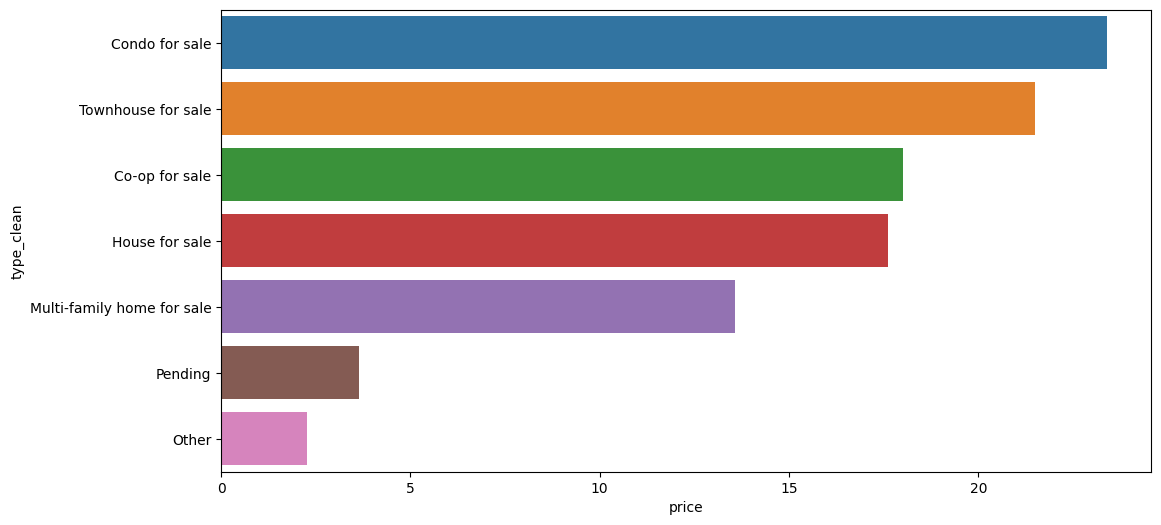

In [194]:
# Calculate market share by types
market_share = (df.groupby('type_clean')['price'].sum() / df.price.sum() * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            x='price',
            y='type_clean',
            hue='type_clean')

<Axes: xlabel='price', ylabel='type_clean'>

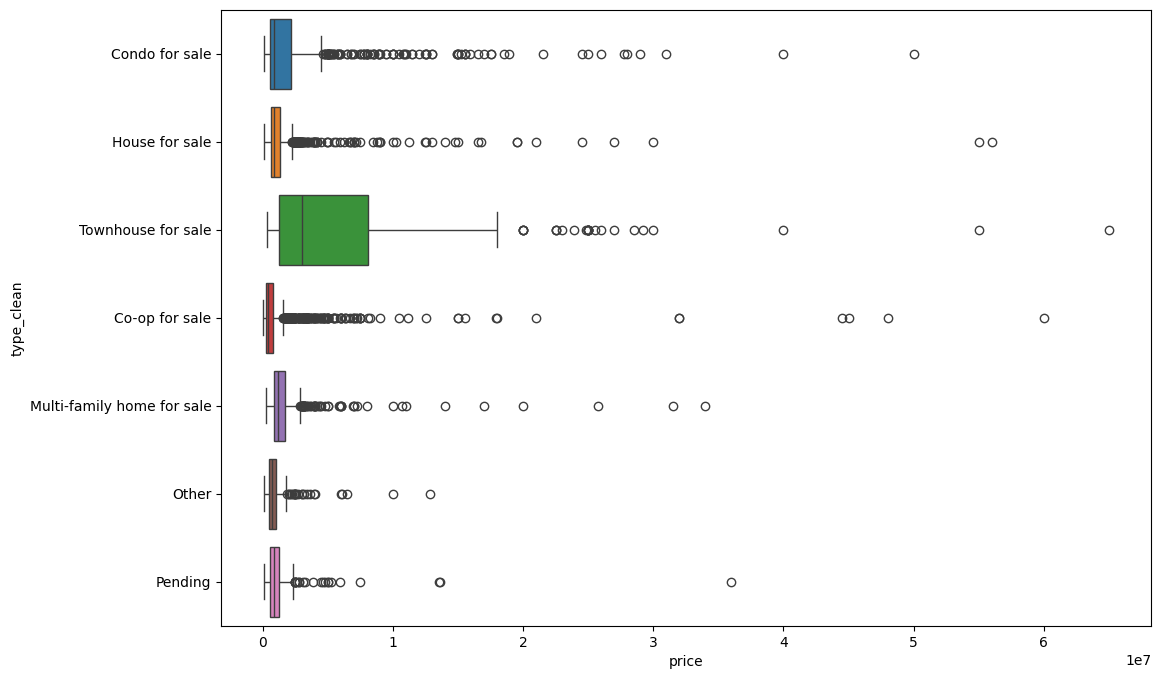

In [195]:
# Create price distribution visualization by property type
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='price', y='type_clean', hue='type_clean')

In [64]:
# Create dummy variables based on type_clean
type_dummies = pd.get_dummies(
    df['type_clean'],
    prefix='type',
    drop_first=True,  # Avoids dummy variable trap
    dtype=int         # Saves memory vs bool
)

# join back to original DataFrame
df = pd.concat([df, type_dummies], axis=1)

### _Beds_

<Axes: xlabel='count', ylabel='beds'>

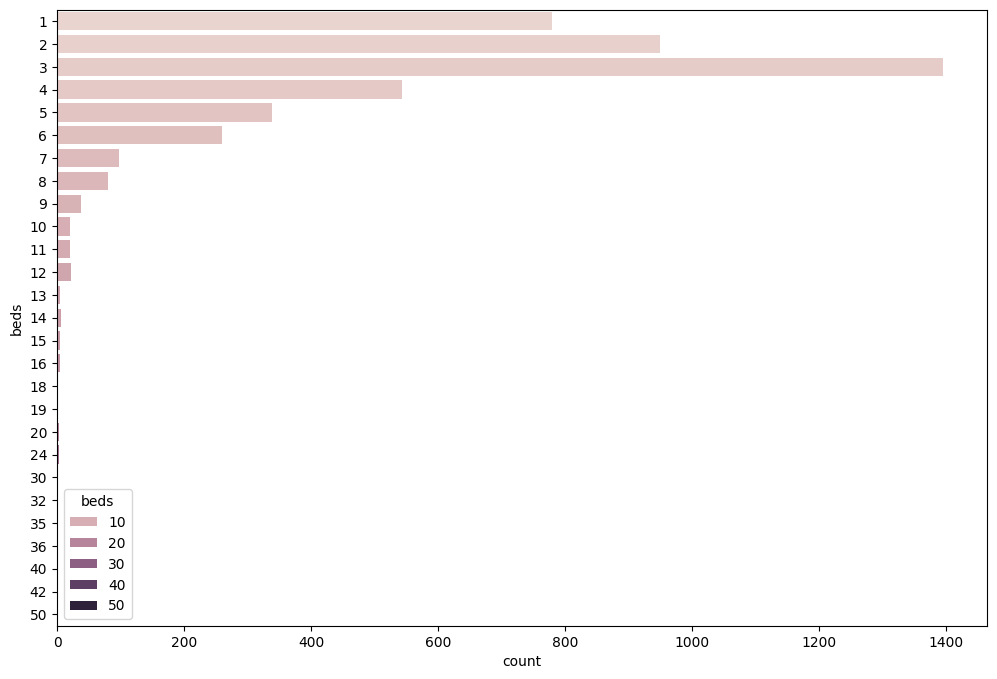

In [196]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='beds', hue='beds')

In [66]:
# Here we also have a skewed distribution

Text(0.5, 1.0, 'Price Distribution by Bedroom Count')

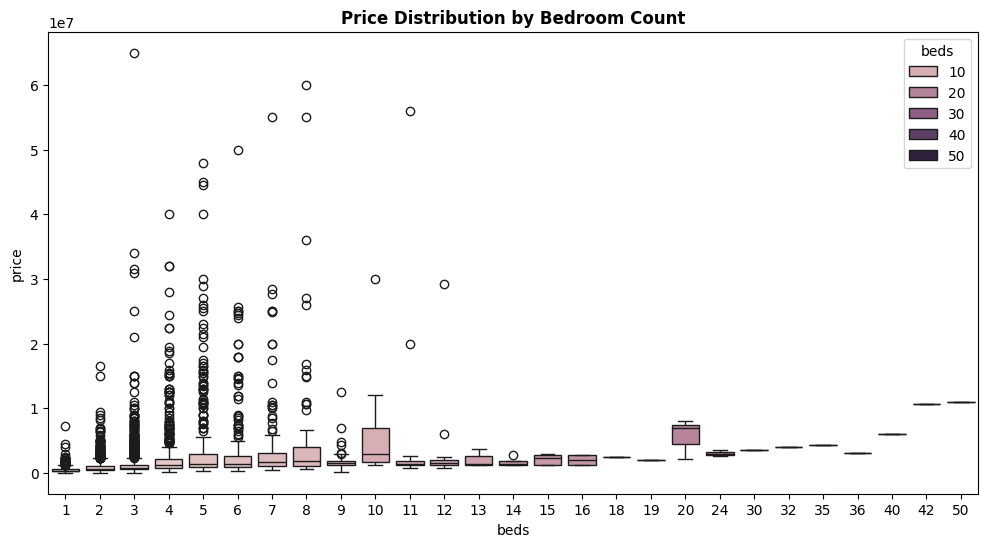

In [197]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,  # Filter outliers
    x='beds',
    y='price',
    showfliers=True,
    hue='beds'
)
#plt.yscale('log')
plt.title('Price Distribution by Bedroom Count', fontweight='bold')

In [68]:
# Market doesn't following beds after 10-12 bedrooms. Most high priced properties have 1-8 bedrooms. So it's probably a good idea divide those groups

Text(0.5, 1.0, 'Price Distribution by Bedroom Count')

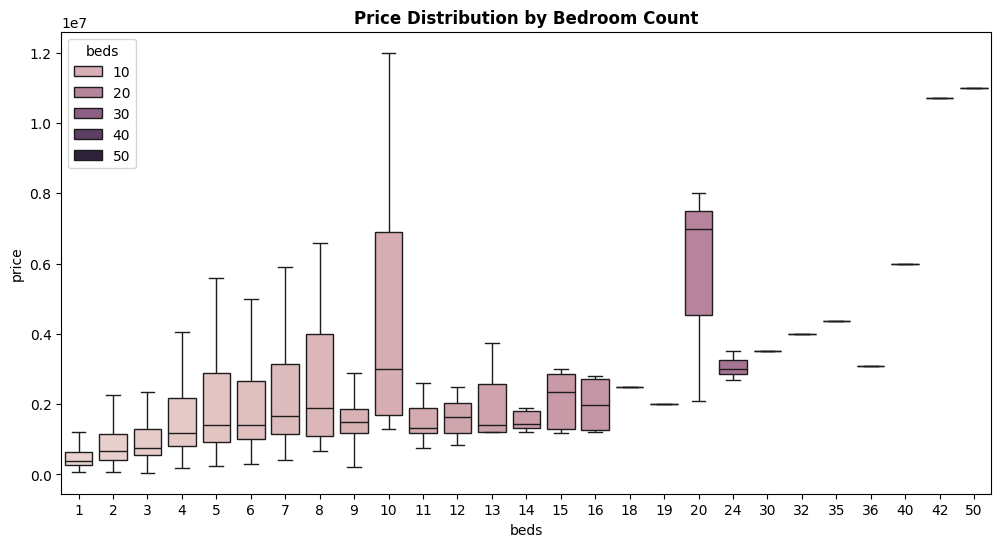

In [198]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,  # Filter outliers
    x='beds',
    y='price',
    showfliers=False,
    hue='beds'
)
#plt.yscale('log')
plt.title('Price Distribution by Bedroom Count', fontweight='bold')

In [70]:
# Here we also see linear relation beds - price up to 10 bedrooms

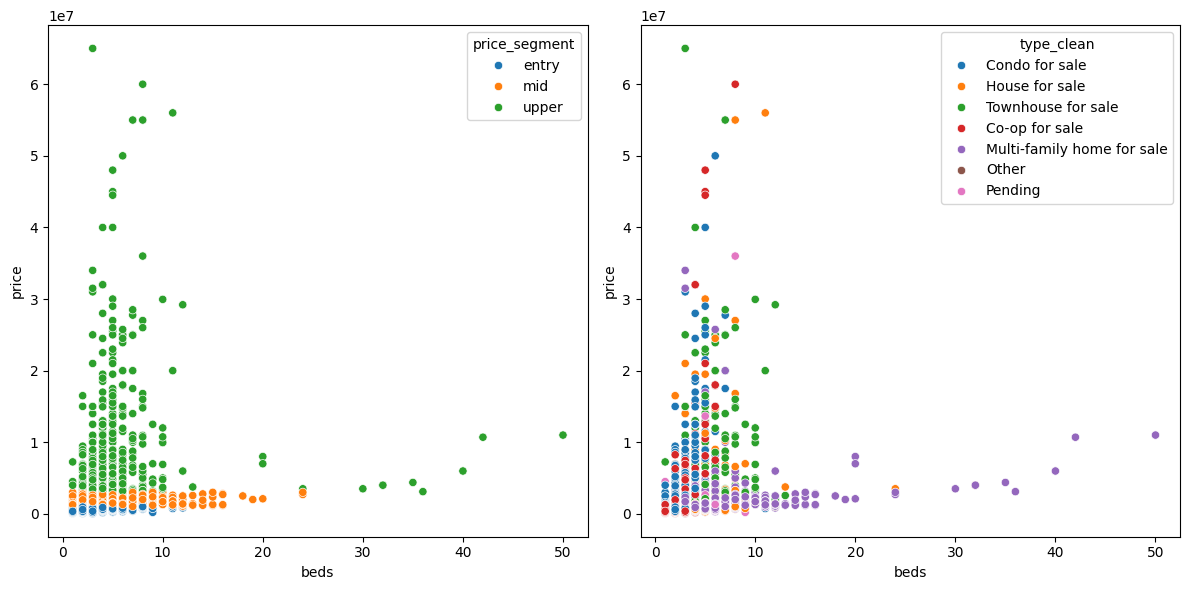

In [71]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
sns.scatterplot(data=df, x='beds', y='price', hue='price_segment')

plt.subplot(1,2,2)
sns.scatterplot(data=df, x='beds', y='price', hue='type_clean')

plt.tight_layout()

In [72]:
# Those properties with high bedroom number are mostly multi-family homes

In [73]:
df[(df.type == 'Multi-family home for sale') & (df.beds > 12) ].price.describe()

count    3.100000e+01
mean     3.257803e+06
std      2.635191e+06
min      1.188888e+06
25%      1.337500e+06
50%      2.700000e+06
75%      3.299500e+06
max      1.100000e+07
Name: price, dtype: float64

In [74]:
# Max price for multi-family house with many bedrooms is 11 mln. I add new price segment for properites with price more then 
# 12 mln (11 mln + margin) for luxury properties

In [75]:
df['price_segment'] = np.where(df.price > 12_000_000, 'luxury', df['price_segment'])

In [260]:
df['is_luxury'] = (df['price'] > 12_000_000).astype(int)

In [76]:
# Need to mention that we CAN NOT use price segment for price modelling
# Probably later we will create a model to predict price segment and look what factors are significant

<Axes: xlabel='beds', ylabel='bath'>

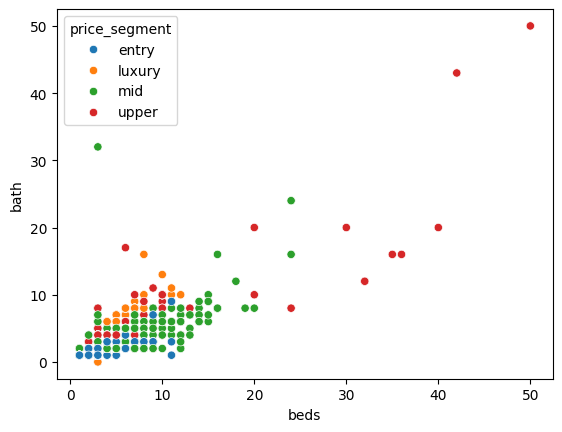

In [77]:
sns.scatterplot(data=df, x='beds', y='bath', hue='price_segment')

In [78]:
# ok, so no luxurios entries in high number bedroom segment

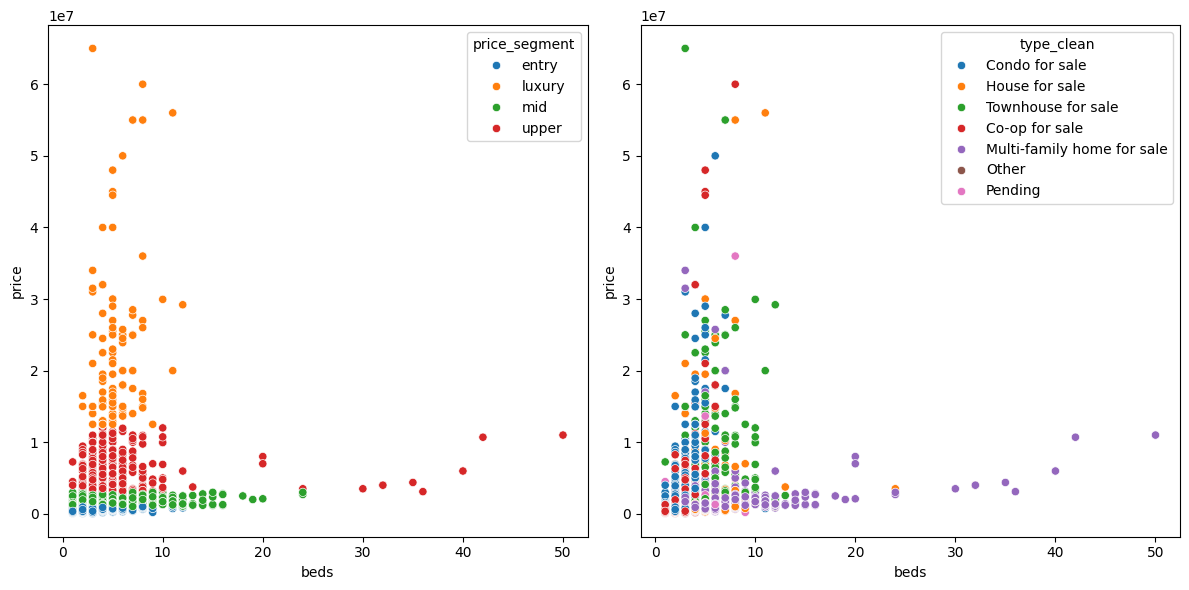

In [79]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
sns.scatterplot(data=df, x='beds', y='price', hue='price_segment')

plt.subplot(1,2,2)
sns.scatterplot(data=df, x='beds', y='price', hue='type_clean')

plt.tight_layout()

In [80]:
df.beds.describe()

count    4582.000000
mean        3.364688
std         2.629057
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        50.000000
Name: beds, dtype: float64

In [81]:
df.beds.value_counts().sort_index()

beds
1      779
2      949
3     1395
4      544
5      339
6      260
7       98
8       81
9       38
10      21
11      20
12      22
13       5
14       6
15       5
16       4
18       1
19       1
20       3
24       3
30       1
32       2
35       1
36       1
40       1
42       1
50       1
Name: count, dtype: int64

<Axes: xlabel='beds', ylabel='count'>

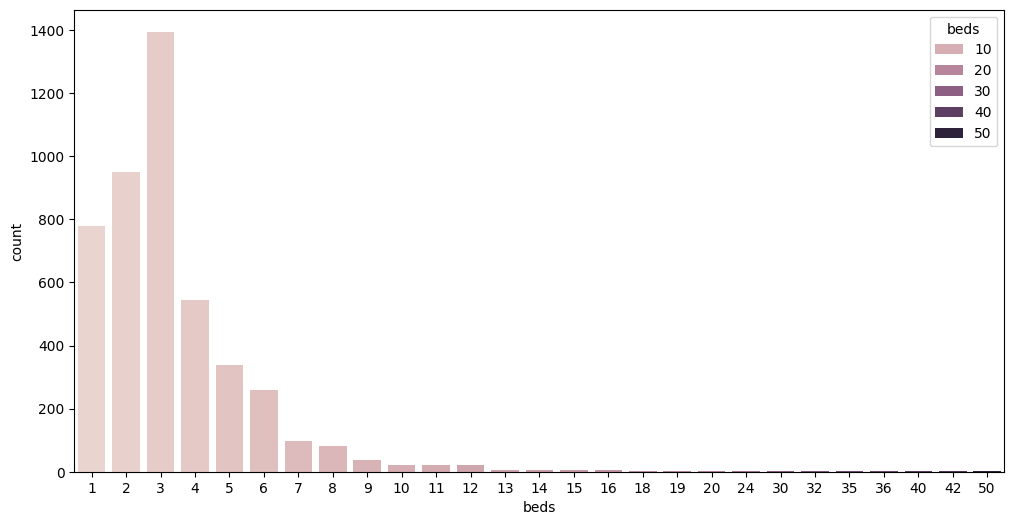

In [201]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='beds', hue='beds')

In [83]:
df['beds'].quantile(0.99)

np.float64(12.0)

In [84]:
# So 12 bedrooms seems as a good threshold

In [85]:
# Flag properties with >12 bedrooms
df['is_high_beds'] = (df['beds'] > 12).astype(int)

<Axes: xlabel='beds', ylabel='price'>

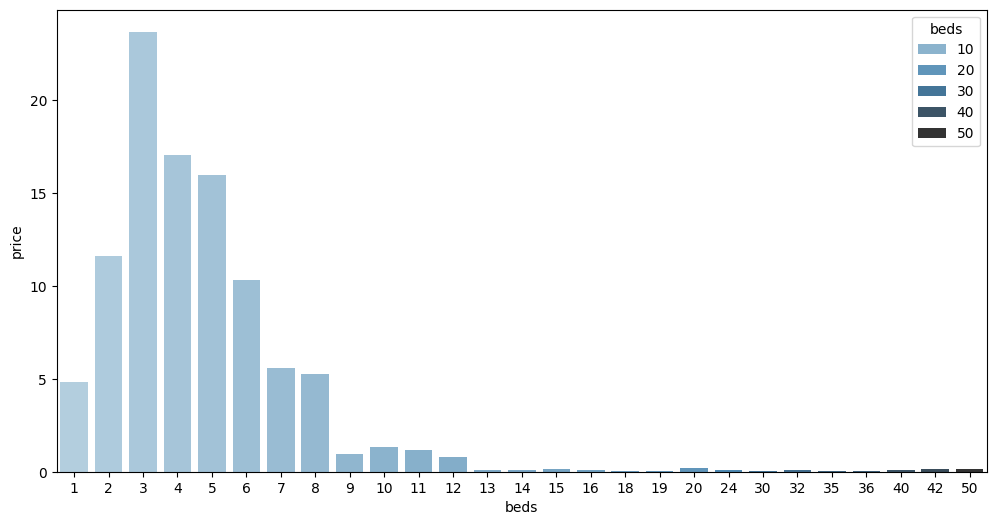

In [86]:
# Calculate market share by bedrooms
market_share = (df.groupby('beds')['price'].sum() / df.price.sum() * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            y='price',
            x='beds',
            hue='beds',
            palette='Blues_d')

<Axes: xlabel='beds', ylabel='price'>

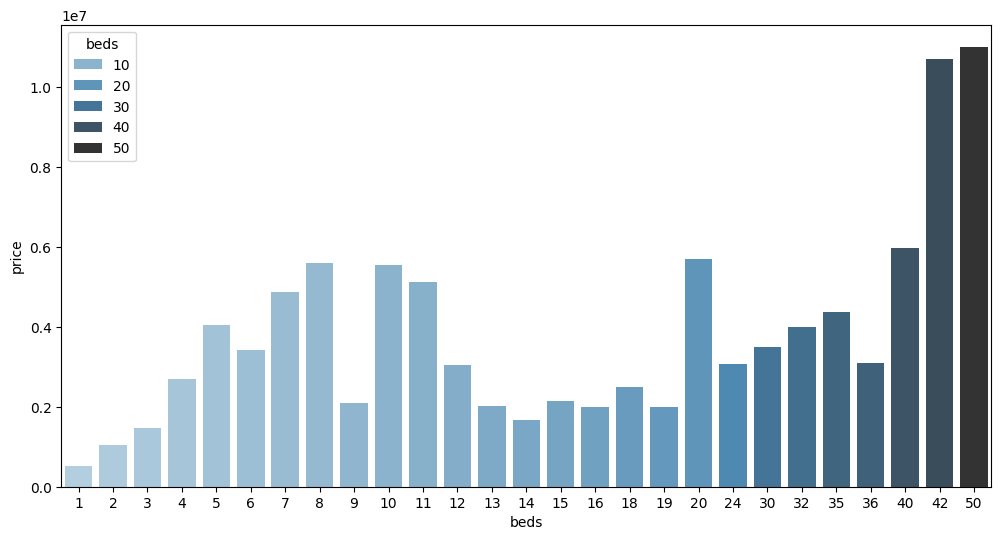

In [87]:
# Mean price dinamic based on number of bedrooms
market_share = (df.groupby('beds')['price'].mean()).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            y='price',
            x='beds',
            hue='beds',
            palette='Blues_d')

In [88]:
# The 1-6 bedroom homes aren’t the most expensive, but they dominate the market – they make up nearly 90% of listings.

In [89]:
df['log_beds'] = np.log1p(df['beds'])

<Axes: xlabel='log_beds', ylabel='Count'>

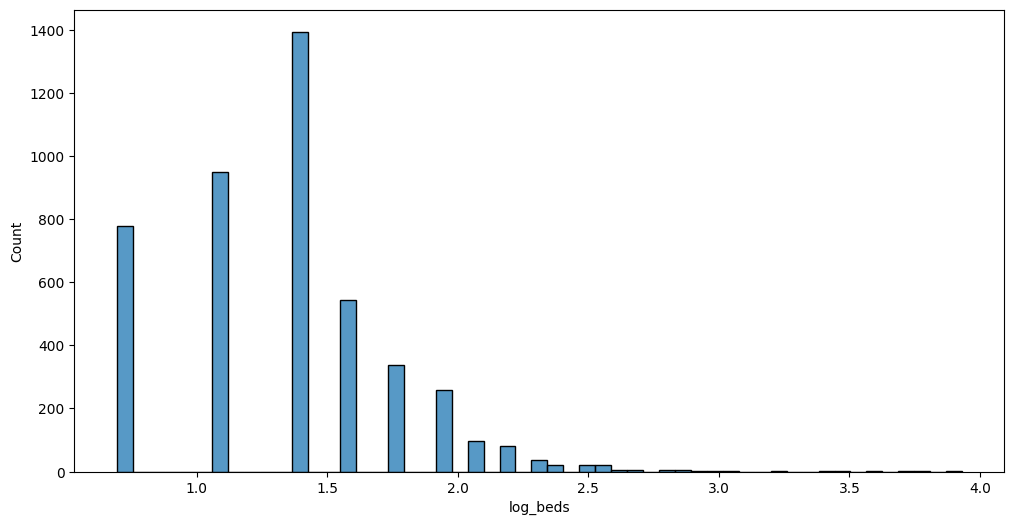

In [202]:
plt.figure(figsize=(12, 6))
sns.histplot(df.log_beds)

### Bath

<Axes: xlabel='count', ylabel='bath'>

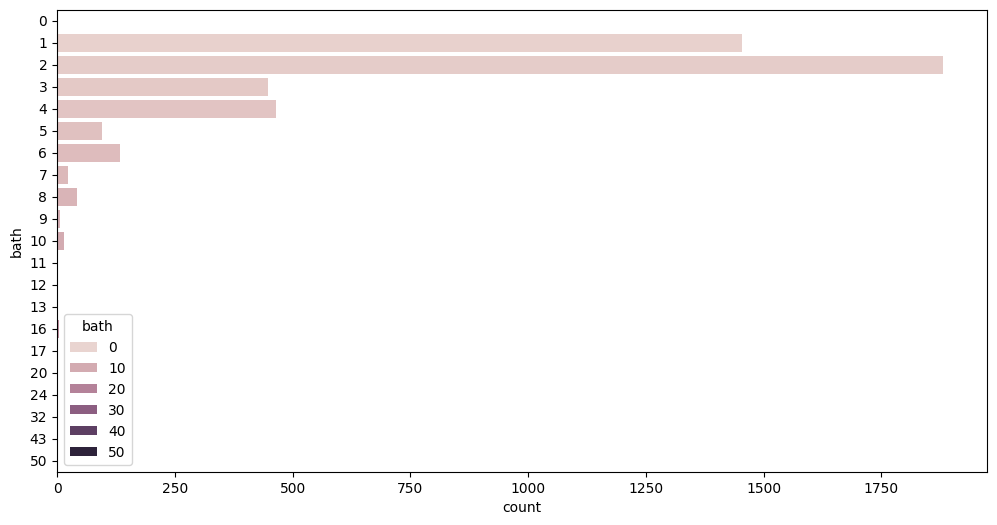

In [203]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='bath', hue='bath')

In [92]:
df.bath.describe()

count    4582.000000
mean        2.352466
std         1.967525
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        50.000000
Name: bath, dtype: float64

Text(0.5, 1.0, 'Price Distribution by Bathroom Count')

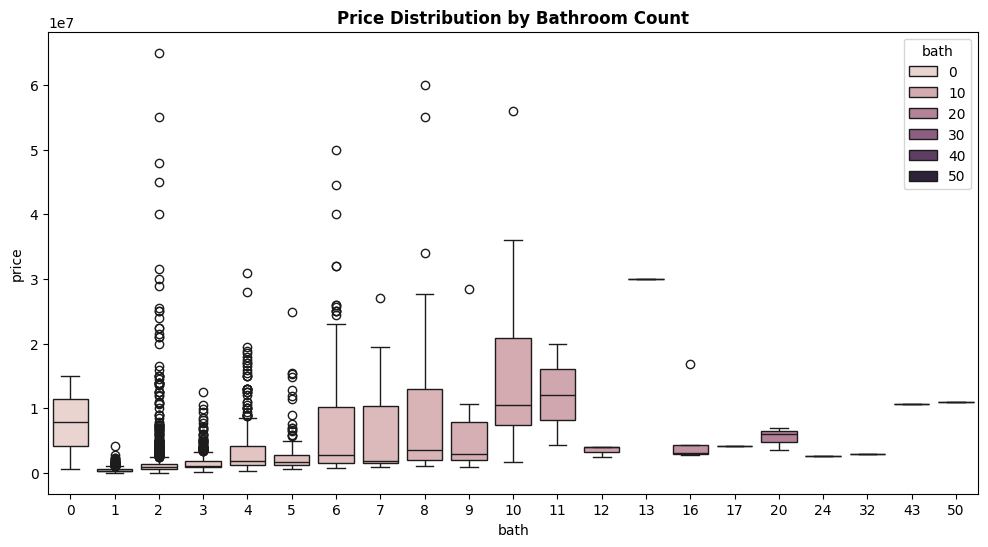

In [204]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,  # Filter outliers
    x='bath',
    y='price',
    showfliers=True,
    hue='bath'
)
#plt.yscale('log')
plt.title('Price Distribution by Bathroom Count', fontweight='bold')

<Axes: ylabel='bath'>

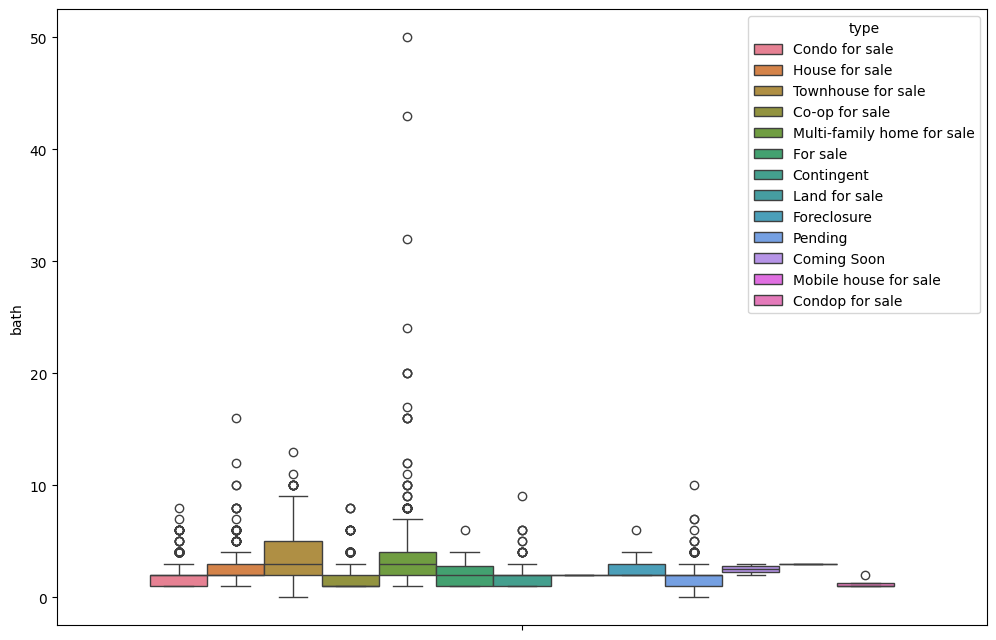

In [94]:
plt.figure(figsize=(12, 8))
sns.boxplot(df,y='bath', hue='type')

<Axes: xlabel='bath', ylabel='log_price'>

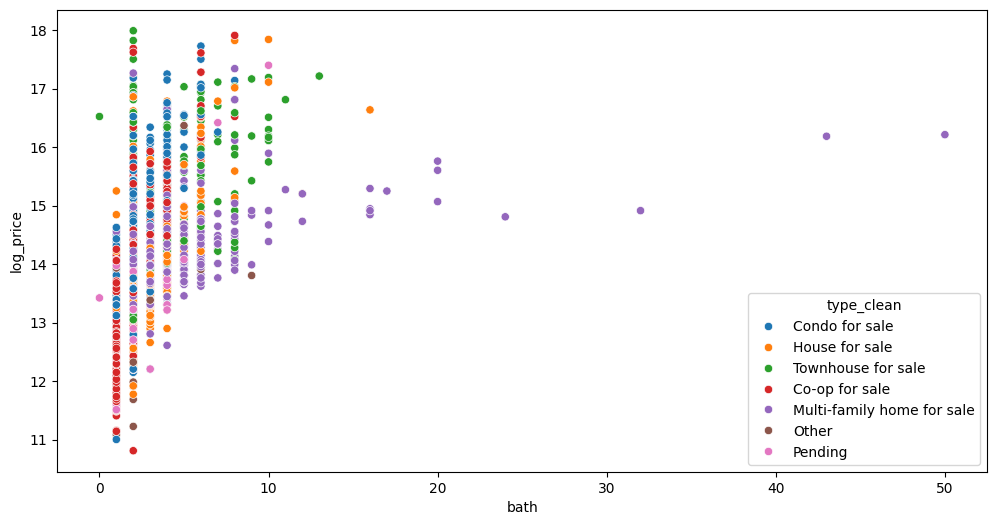

In [95]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='bath', y='log_price', hue='type_clean')

<Axes: xlabel='bath', ylabel='price'>

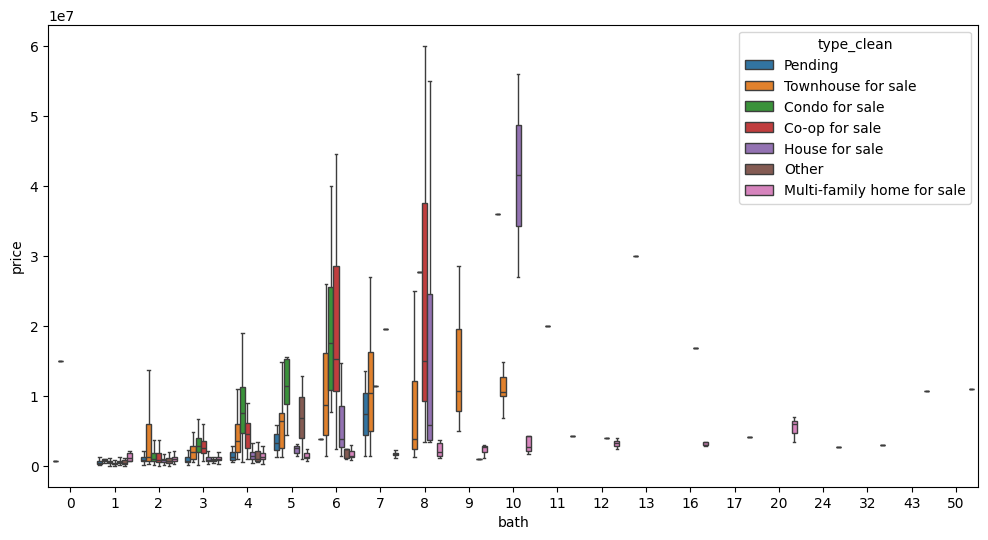

In [96]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='bath', y='price', hue='type_clean', showfliers=False)

<Axes: xlabel='bath', ylabel='log_price'>

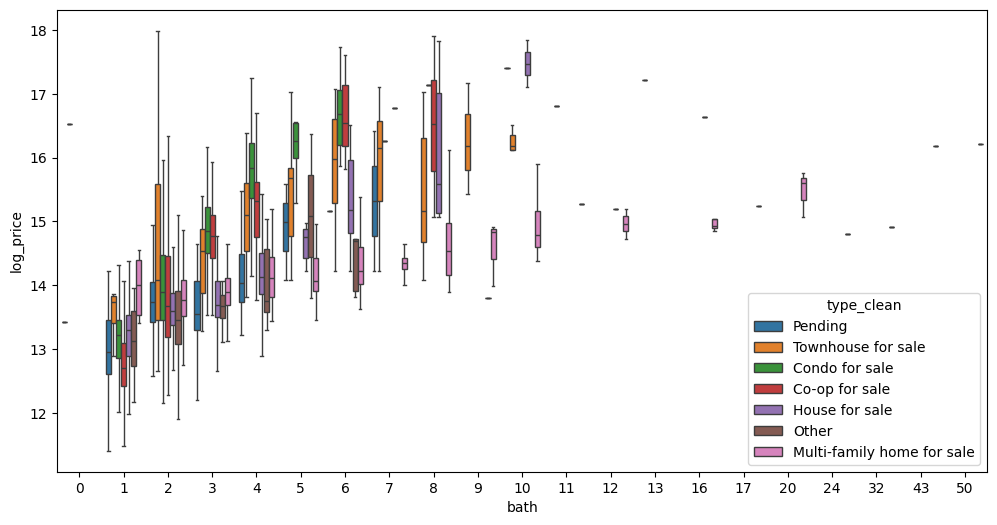

In [97]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='bath', y='log_price', hue='type_clean', showfliers=False)

<Axes: xlabel='bath', ylabel='price'>

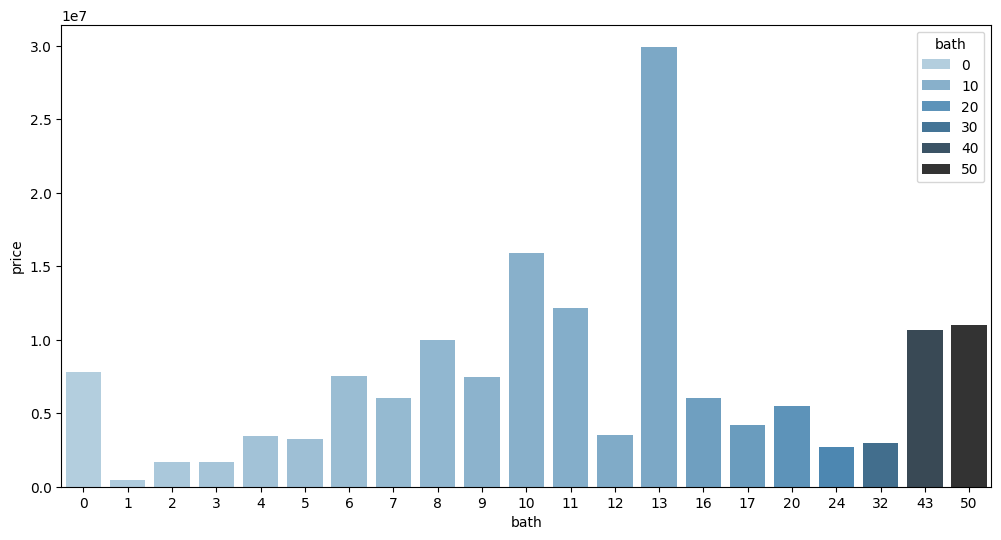

In [98]:
# Mean price dinamic based on number of bathrooms
market_share = (df.groupby('bath')['price'].mean()).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            y='price',
            x='bath',
            hue='bath',
            palette='Blues_d')

In [99]:
df['log_bath'] = np.log1p(df.bath)

<Axes: xlabel='log_beds', ylabel='Count'>

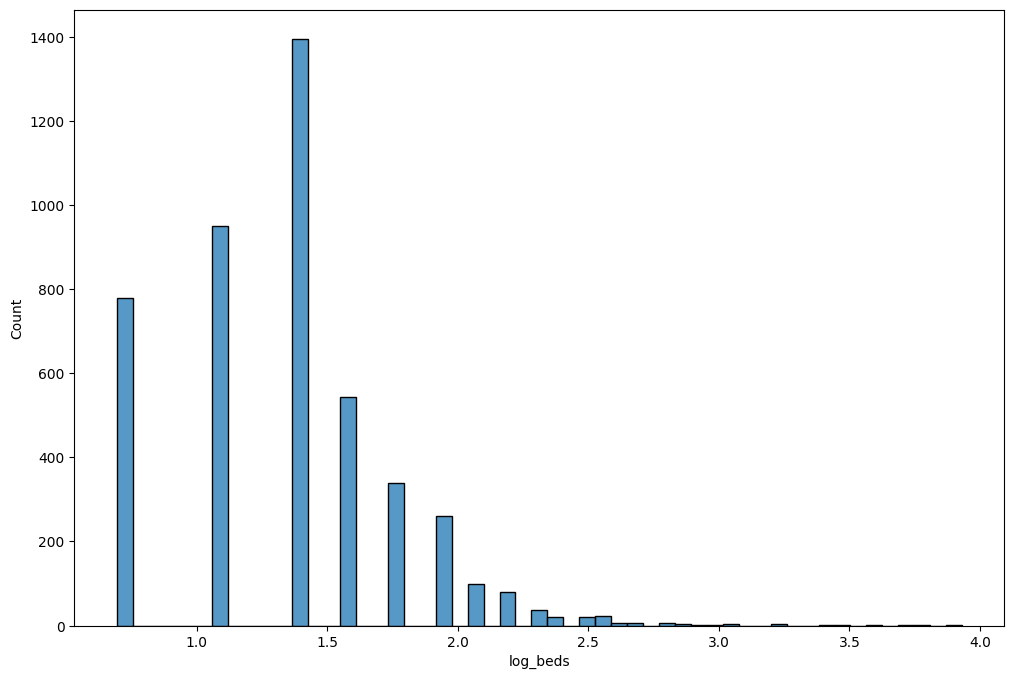

In [100]:
plt.figure(figsize=(12, 8))
sns.histplot(df.log_beds)

### *Propertysqft*

<Axes: xlabel='propertysqft', ylabel='Count'>

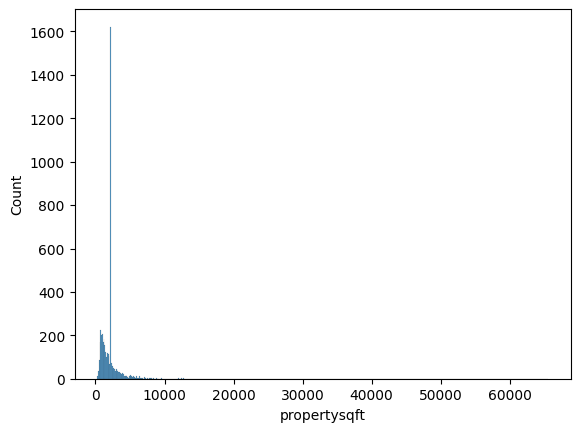

In [101]:
sns.histplot(df.propertysqft)

In [102]:
df.propertysqft.value_counts()

propertysqft
2184.207862     1536
800.000000        54
900.000000        51
750.000000        51
1200.000000       48
                ... 
2002.000000        1
2090.000000        1
886.000000         1
2367.000000        1
12733.000000       1
Name: count, Length: 1444, dtype: int64

In [103]:
df.propertysqft.describe()

count     4582.000000
mean      2172.647158
std       2270.083992
min        230.000000
25%       1200.000000
50%       2184.207862
75%       2184.207862
max      65535.000000
Name: propertysqft, dtype: float64

In [104]:
# The value 2184.207862 appears to have been used as a substitute for missing values.

In [105]:
df[df.propertysqft!=2184.207862].propertysqft.describe()

count     3046.000000
mean      2166.817466
std       2784.361263
min        230.000000
25%        953.500000
50%       1495.500000
75%       2455.000000
max      65535.000000
Name: propertysqft, dtype: float64

In [106]:
# On the dataset without 2184.207862, the median is 1495.50. I’ll impute missing values with this median and mark them with the area_missing flag.

In [107]:
df['area_missing'] = np.where(df['propertysqft'] == 2184.207862, 1, 0)

In [108]:
df['area_missing'].value_counts()

area_missing
0    3046
1    1536
Name: count, dtype: int64

In [109]:
df['propertysqft'] = np.where(df['area_missing'] == 1, 1495.512345, df['propertysqft'])

In [110]:
df.propertysqft.describe()

count     4582.000000
mean      1941.779346
std       2292.087025
min        230.000000
25%       1200.000000
50%       1495.512345
75%       1887.750000
max      65535.000000
Name: propertysqft, dtype: float64

<Axes: ylabel='propertysqft'>

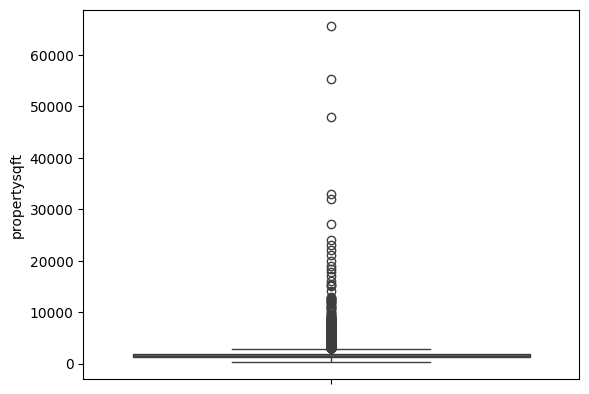

In [111]:
sns.boxplot(df.propertysqft)

<Axes: xlabel='propertysqft', ylabel='Count'>

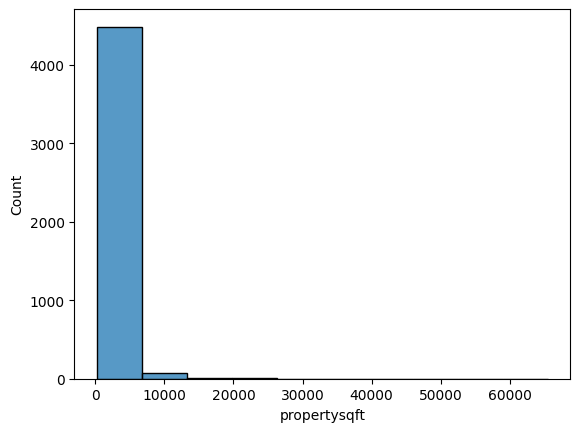

In [112]:
sns.histplot(df.propertysqft, bins=10)

In [113]:
df['propertysqft'].quantile(0.995)

np.float64(12513.660000000058)

In [114]:
# Propertysqft data looks highly skewed. I'll apply log transform to compensate

In [115]:
df['log_area'] = np.log1p(df.propertysqft)

<Axes: xlabel='log_area', ylabel='Count'>

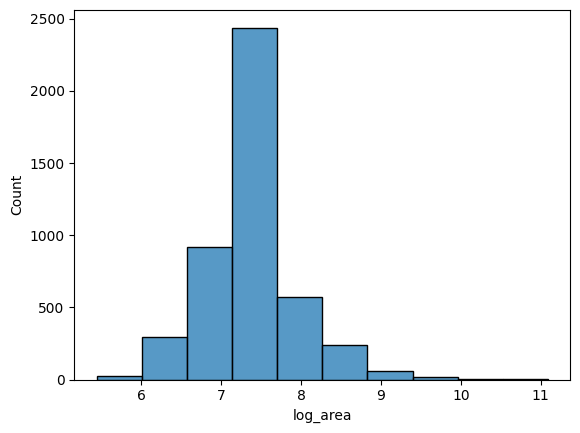

In [116]:
sns.histplot(df.log_area, bins=10)

<Axes: xlabel='log_area', ylabel='log_price'>

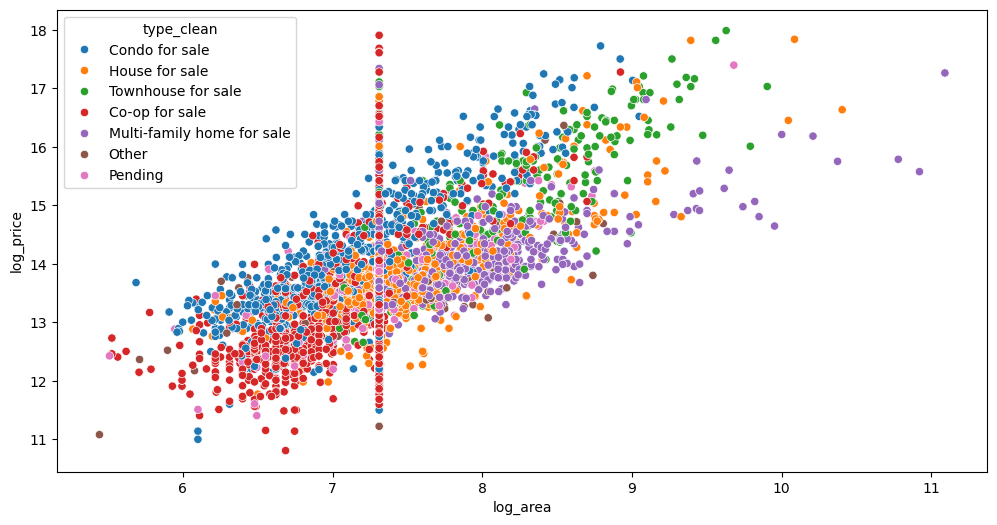

In [117]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='log_area', y='log_price', hue='type_clean')

In [118]:
# In this graph, we can observe data clustering. The vertical line of dots corresponds to the substituted value that was used 
# to fill in missing entries. The most expensive properties across all area ranges are condos.

In [119]:
df.columns

Index(['type', 'price', 'beds', 'bath', 'propertysqft', 'address', 'state',
       'main_address', 'administrative_area_level_2', 'locality',
       'sublocality', 'street_name', 'long_name', 'formatted_address',
       'latitude', 'longitude', 'is_upper', 'is_mid', 'price_segment',
       'log_price', 'type_clean', 'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds', 'log_bath',
       'area_missing', 'log_area'],
      dtype='object')

### All address data

In [120]:
address_columns = ['address', 'state',
       'main_address', 'administrative_area_level_2', 'locality',
       'sublocality', 'street_name', 'long_name', 'formatted_address']

In [121]:
df[address_columns].head(7)

,address,state,main_address,administrative_area_level_2,locality,sublocality,street_name,long_name,formatted_address
0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N..."
1,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA"
2,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA"
3,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA"
4,584 Park Pl,"Brooklyn, NY 11238","584 Park PlBrooklyn, NY 11238",United States,New York,Kings County,Brooklyn,Park Place,"584 Park Pl, Brooklyn, NY 11238, USA"
5,157 W 126th St Unit 1B,"New York, NY 10027","157 W 126th St Unit 1BNew York, NY 10027",New York,New York County,New York,Manhattan,157,"157 W 126th St #1b, New York, NY 10027, USA"
6,177 Benedict Rd,"Staten Island, NY 10304","177 Benedict RdStaten Island, NY 10304",United States,New York,Richmond County,Staten Island,Benedict Road,"177 Benedict Rd, Staten Island, NY 10304, USA"


In [122]:
# Address and formatted address probably should be dropped.

In [123]:
# State contain zip. Could be usefull

In [124]:
df['zip'] = df['state'].str[-5:]

# Filter invalid ZIPs (e.g., non-numeric)
df['zip'] = df['zip'].where(df['zip'].str.isdigit())

In [125]:
df.zip.isna().sum()

np.int64(0)

In [126]:
df.zip.value_counts()

zip
11375    102
11235    100
11209     91
11234     89
10314     81
        ... 
11040      1
11364      1
10455      1
10282      1
11416      1
Name: count, Length: 178, dtype: int64

In [127]:
df.state.value_counts()

state
Brooklyn, NY 11235            99
Brooklyn, NY 11209            91
Forest Hills, NY 11375        88
Brooklyn, NY 11234            86
Staten Island, NY 10314       80
                              ..
Ditmas Park, NY 11226          1
Jackson Heights, NY 11370      1
New York, NY 10282             1
Long Island City, NY 11106     1
Ozone Park, NY 11416           1
Name: count, Length: 307, dtype: int64

In [128]:
df.administrative_area_level_2.value_counts()

administrative_area_level_2
United States      2372
New York           2135
New York County      21
11214                 8
Kings County          6
Queens County         6
Bronx County          4
11229                 3
10003                 2
10017                 2
10310                 2
10471                 2
10306                 2
10002                 2
11414                 1
11417                 1
11234                 1
10309                 1
10301                 1
10303                 1
10463                 1
10304                 1
10312                 1
10465                 1
11412                 1
Brooklyn              1
10466                 1
11237                 1
11218                 1
Name: count, dtype: int64

In [129]:
# Messy feature, better should use borough

In [130]:
#locality	sublocality	street_name	long_name

In [131]:
df.locality.value_counts()

locality
New York           2393
New York County     928
Queens County       536
Kings County        441
Bronx County        172
Richmond County      58
United States        37
Queens                6
Brooklyn              6
The Bronx             4
Flatbush              1
Name: count, dtype: int64

In [132]:
df.sublocality.value_counts()

sublocality
New York            965
Kings County        696
Queens County       655
Queens              534
Richmond County     460
Brooklyn            441
Bronx County        291
New York County     270
The Bronx           174
Staten Island        58
Manhattan            21
Flushing              4
Coney Island          3
Riverdale             3
East Bronx            1
Jackson Heights       1
Brooklyn Heights      1
Rego Park             1
Fort Hamilton         1
Dumbo                 1
Snyder Avenue         1
Name: count, dtype: int64

In [133]:
df.street_name.value_counts()

street_name
Manhattan          928
Brooklyn           696
Queens             655
Staten Island      460
The Bronx          294
                  ... 
2501                 1
67th Drive           1
Todt Hill            1
Saunders Street      1
Mount Eden           1
Name: count, Length: 174, dtype: int64

In [134]:
df.long_name.value_counts()

long_name
2                   19
200                 18
100                 18
50                  15
40                  14
                    ..
65th Road            1
7666                 1
Kenmore Court        1
Corbin Avenue        1
West 87th Street     1
Name: count, Length: 2729, dtype: int64

In [135]:
address_columns

['address',
 'state',
 'main_address',
 'administrative_area_level_2',
 'locality',
 'sublocality',
 'street_name',
 'long_name',
 'formatted_address']

In [136]:
df = df.drop(columns=address_columns)

In [137]:
# Reset index after cleaning
df = df.reset_index(drop=True)

### Add boroughs

In [140]:
boroughs_file = '../data/nyc_boroughs.geojson'

In [141]:
gdf_boroughs = gpd.read_file(boroughs_file)

<Axes: >

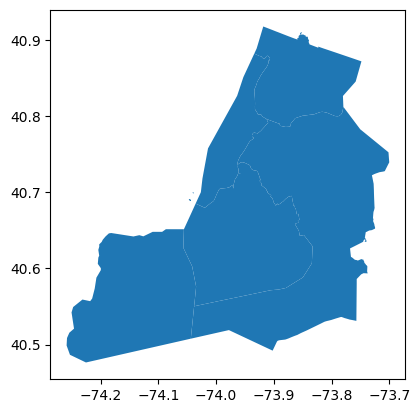

In [143]:
gdf_boroughs.plot()

In [145]:
gdf_boroughs

,name,geometry
0,The Bronx,"MULTIPOLYGON (((-73.93263 40.81897, -73.93274 ..."
1,Brooklyn,"MULTIPOLYGON (((-73.99426 40.70403, -73.99341 ..."
2,Queens,"MULTIPOLYGON (((-73.76604 40.7984, -73.75637 4..."
3,Manhattan,"MULTIPOLYGON (((-74.03993 40.69859, -74.04008 ..."
4,Staten Island,"MULTIPOLYGON (((-74.03805 40.55034, -74.03634 ..."


In [146]:
gdf_houses = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs=gdf_boroughs.crs
)

In [148]:
df_with_borough = gpd.sjoin(
    gdf_houses,
    gdf_boroughs[['name', 'geometry']],  # Only keep needed columns
    how='left',
    predicate='within'
)

In [149]:
df_with_borough

,type,price,beds,bath,propertysqft,latitude,longitude,is_upper,is_mid,price_segment,...,type_Townhouse for sale,is_high_beds,log_beds,log_bath,area_missing,log_area,zip,geometry,index_right,name
0,Condo for sale,315000,2,2,1400.000000,40.761255,-73.974483,0,0,entry,...,0,0,1.098612,1.098612,0,7.244942,10022,POINT (-73.97448 40.76126),3,Manhattan
1,House for sale,260000,4,2,2015.000000,40.541805,-74.196109,0,0,entry,...,0,0,1.609438,1.098612,0,7.608871,10312,POINT (-74.19611 40.54181),4,Staten Island
2,Condo for sale,69000,3,1,445.000000,40.761398,-73.974613,0,0,entry,...,0,0,1.386294,0.693147,0,6.100319,10022,POINT (-73.97461 40.7614),3,Manhattan
3,Townhouse for sale,55000000,7,2,14175.000000,40.767224,-73.969856,1,0,luxury,...,1,0,2.079442,1.098612,0,9.559306,10065,POINT (-73.96986 40.76722),3,Manhattan
4,House for sale,690000,5,2,4004.000000,40.674363,-73.958725,0,0,entry,...,0,0,1.791759,1.098612,0,8.295299,11238,POINT (-73.95872 40.67436),1,Brooklyn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4577,Co-op for sale,599000,1,1,1495.512345,40.774350,-73.955879,0,0,entry,...,0,0,0.693147,0.693147,1,7.310893,10075,POINT (-73.95588 40.77435),3,Manhattan
4578,Co-op for sale,245000,1,1,1495.512345,40.732538,-73.860152,0,0,entry,...,0,0,0.693147,0.693147,1,7.310893,11374,POINT (-73.86015 40.73254),2,Queens
4579,Co-op for sale,1275000,1,1,1495.512345,40.745882,-74.003398,0,1,mid,...,0,0,0.693147,0.693147,1,7.310893,10011,POINT (-74.0034 40.74588),3,Manhattan
4580,Condo for sale,598125,2,1,655.000000,40.742770,-73.872752,0,0,entry,...,0,0,1.098612,0.693147,0,6.486161,11373,POINT (-73.87275 40.74277),2,Queens


In [150]:
df['borough'] = df_with_borough['name']

In [153]:
df['borough'].isna().sum()

np.int64(0)

In [154]:
# Nothing missing

<Axes: xlabel='longitude', ylabel='latitude'>

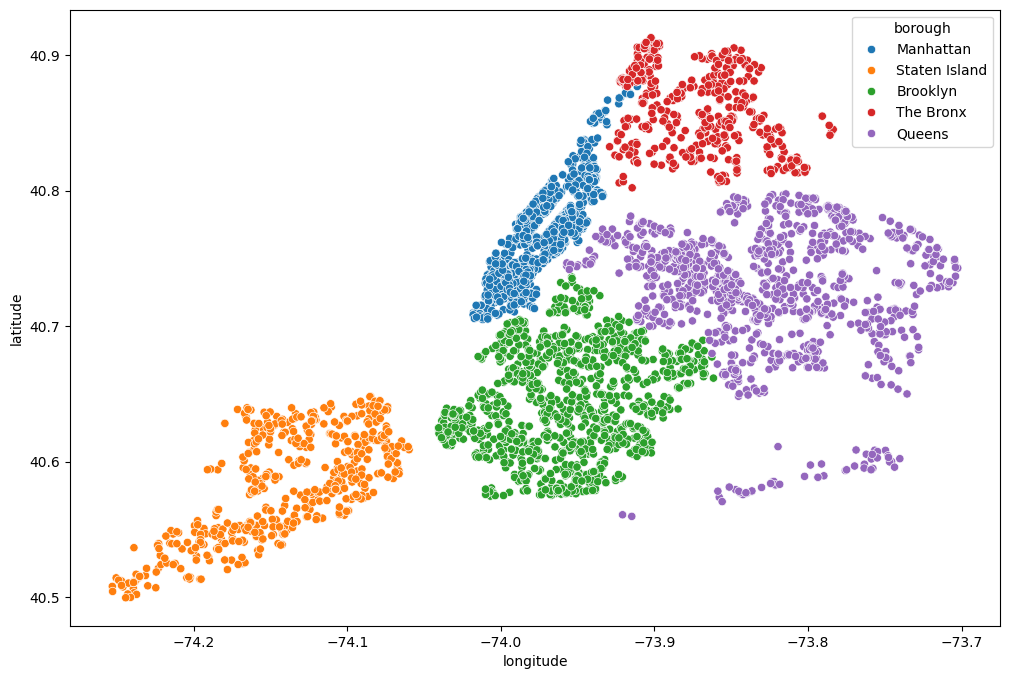

In [151]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="borough", data=df)

In [152]:
# Looks great!

<Axes: xlabel='price', ylabel='borough'>

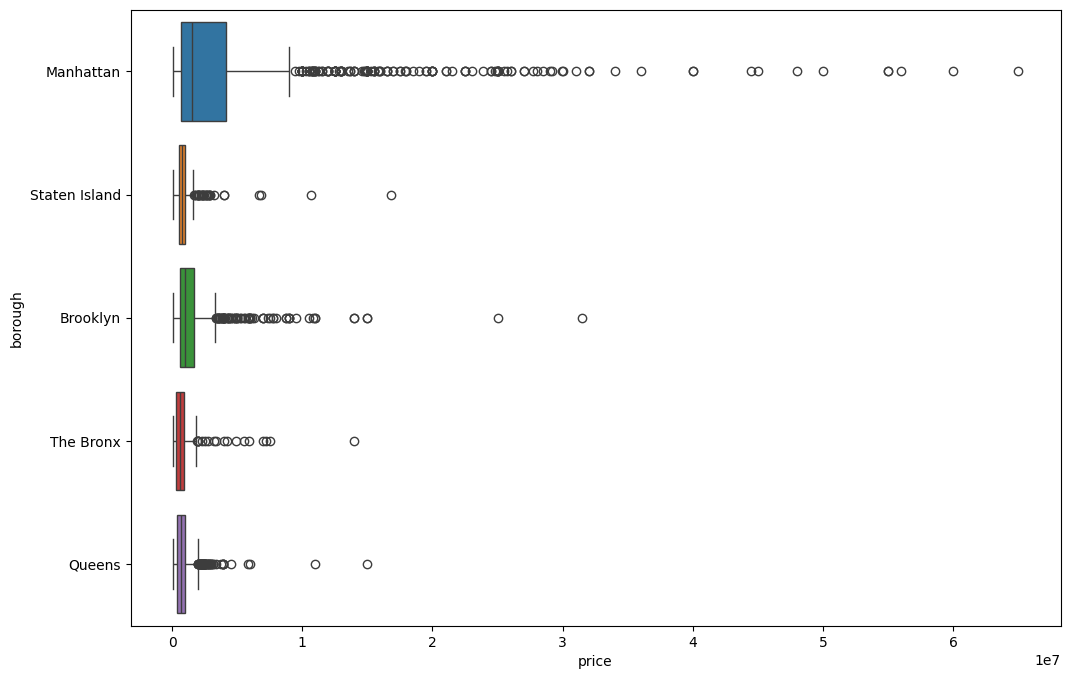

In [160]:
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='price', y='borough', hue='borough')

<Axes: xlabel='log_price', ylabel='borough'>

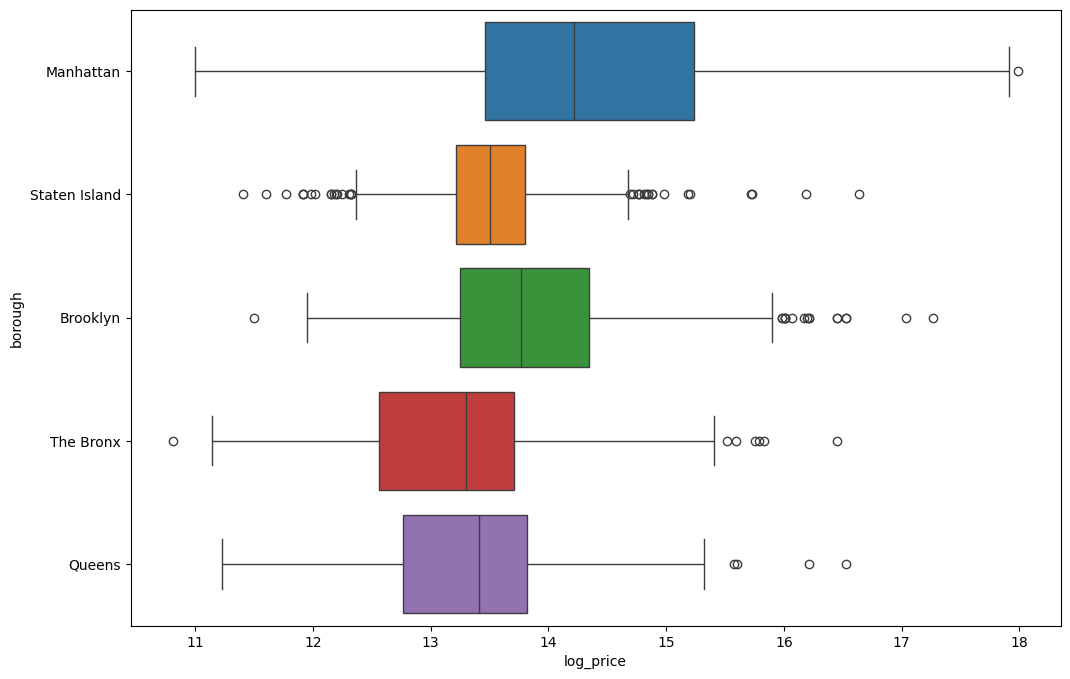

In [161]:
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='log_price', y='borough', hue='borough')

In [162]:
df.columns

Index(['type', 'price', 'beds', 'bath', 'propertysqft', 'latitude',
       'longitude', 'is_upper', 'is_mid', 'price_segment', 'log_price',
       'type_clean', 'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds', 'log_bath',
       'area_missing', 'log_area', 'zip', 'borough'],
      dtype='object')

<Axes: xlabel='beds', ylabel='borough'>

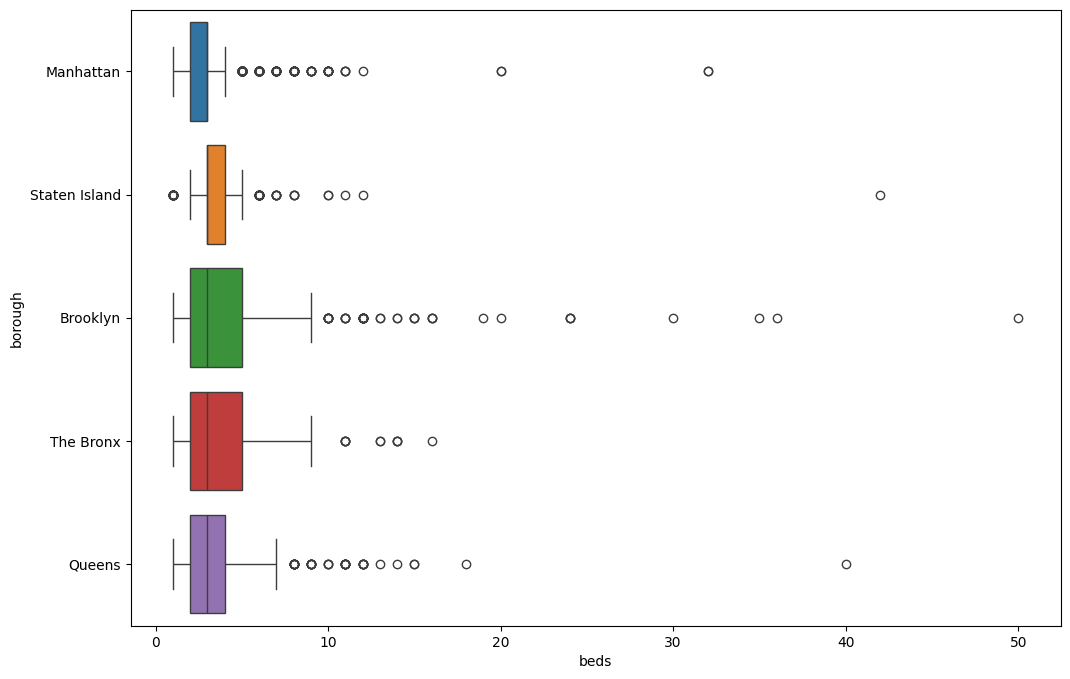

In [163]:
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='beds', y='borough', hue='borough')

<Axes: xlabel='bath', ylabel='borough'>

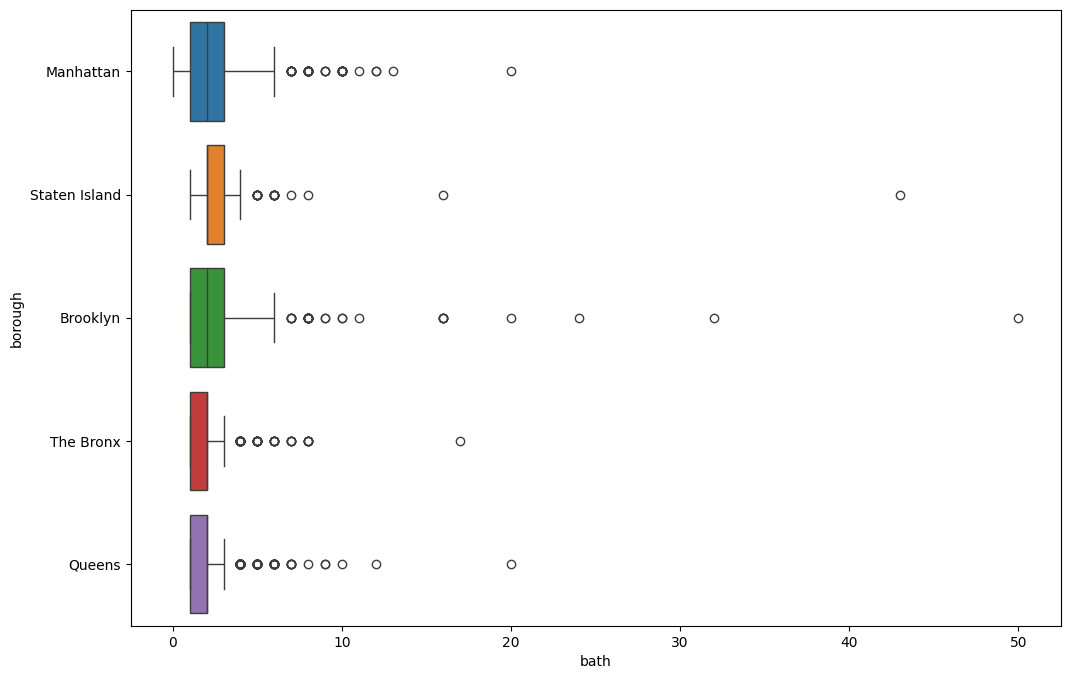

In [164]:
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='bath', y='borough', hue='borough')

<Axes: xlabel='borough', ylabel='count'>

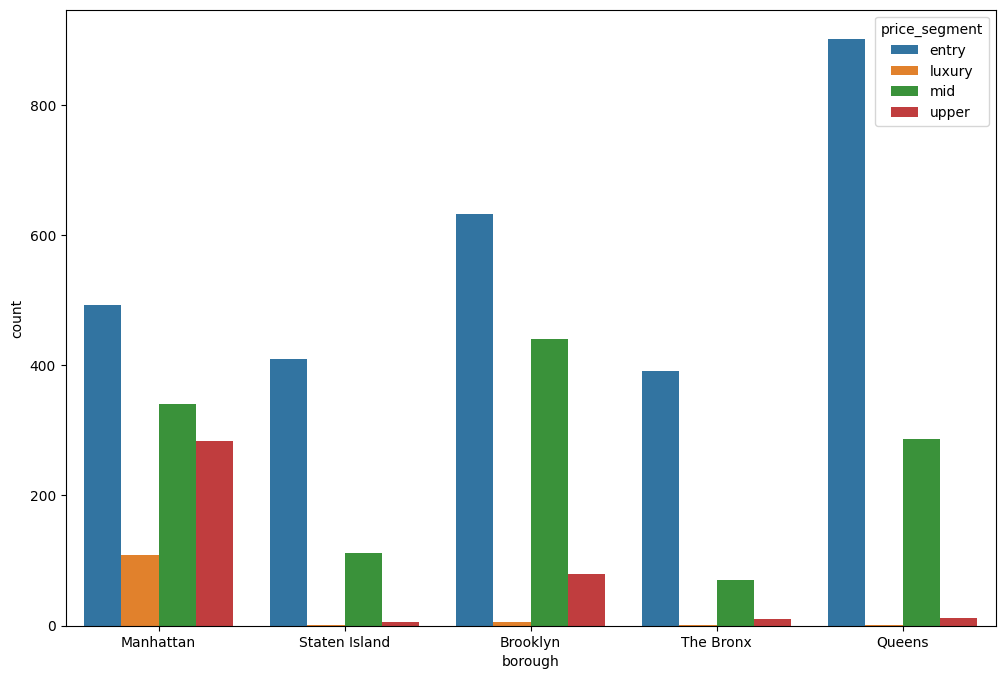

In [169]:
plt.figure(figsize=(12, 8))
sns.countplot(df, x='borough', hue='price_segment')

In [ ]:
plt.figure(figsize=(12, 8))
sns.countplot(df, x='bath', y='borough', hue='borough')

<Axes: xlabel='borough', ylabel='price'>

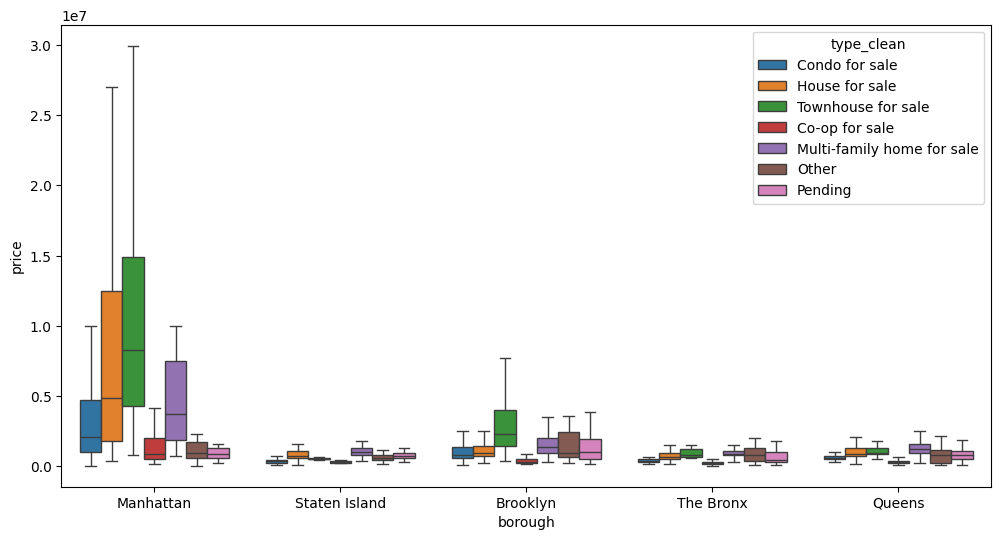

In [189]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='borough', y='price', hue='type_clean', showfliers=False)

<Axes: xlabel='count', ylabel='borough'>

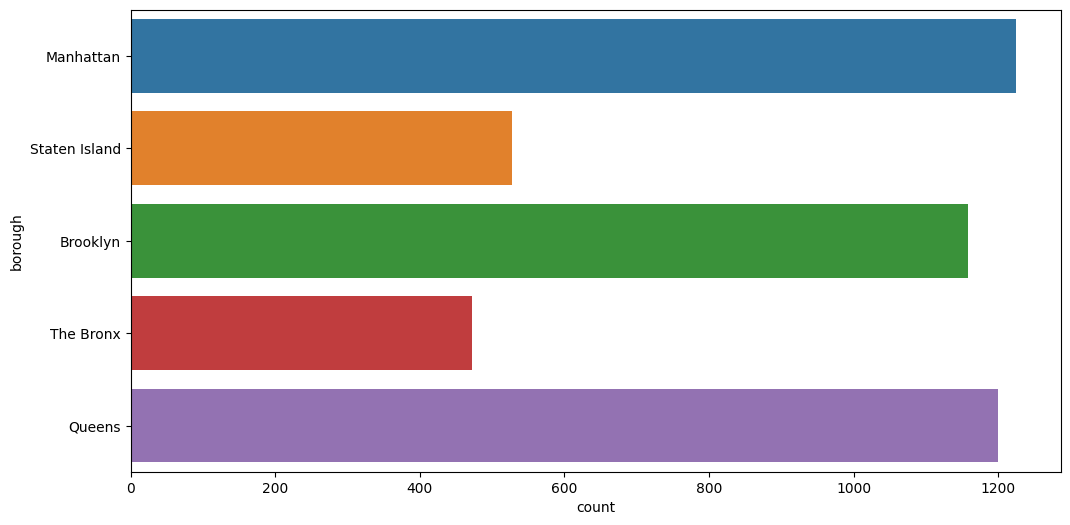

In [177]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='borough', hue='borough')

<Axes: xlabel='price', ylabel='borough'>

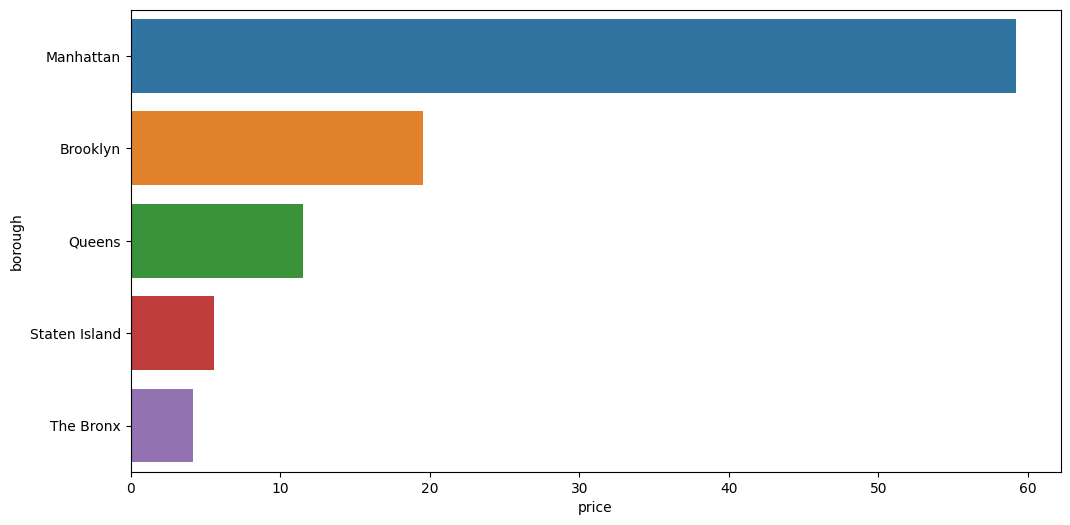

In [173]:
# Calculate market share by types
market_share = (df.groupby('borough')['price'].sum() / df.price.sum() * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            x='price',
            y='borough',
           hue='borough')

In [174]:
# Ok, those plots confirm what we already know, all the money is in Manhattan.

In [179]:
df.borough.value_counts()

borough
Manhattan        1225
Queens           1200
Brooklyn         1158
Staten Island     527
The Bronx         472
Name: count, dtype: int64

In [185]:
# Enconding for boroughs. Only top boroughs
borough_dummies = pd.get_dummies(df['borough'], prefix='borough')

top_boroughs = ['borough_Manhattan', 'borough_Brooklyn', 'borough_Queens']
df = pd.concat([df, borough_dummies[top_boroughs]], axis=1)

## Correlation

In [205]:
df.columns

Index(['type', 'price', 'beds', 'bath', 'propertysqft', 'latitude',
       'longitude', 'is_upper', 'is_mid', 'price_segment', 'log_price',
       'type_clean', 'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds', 'log_bath',
       'area_missing', 'log_area', 'zip', 'borough', 'borough_Manhattan',
       'borough_Brooklyn', 'borough_Queens'],
      dtype='object')

In [206]:
numerical_columns = ['price', 'beds', 'bath', 'propertysqft',
       'log_price','log_beds', 'log_bath',
       'log_area']

In [207]:
corr = df[numerical_columns].corr()

<Axes: >

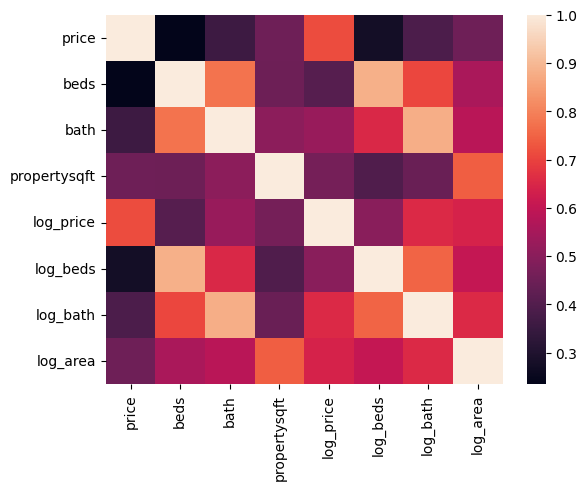

In [208]:
sns.heatmap(corr)

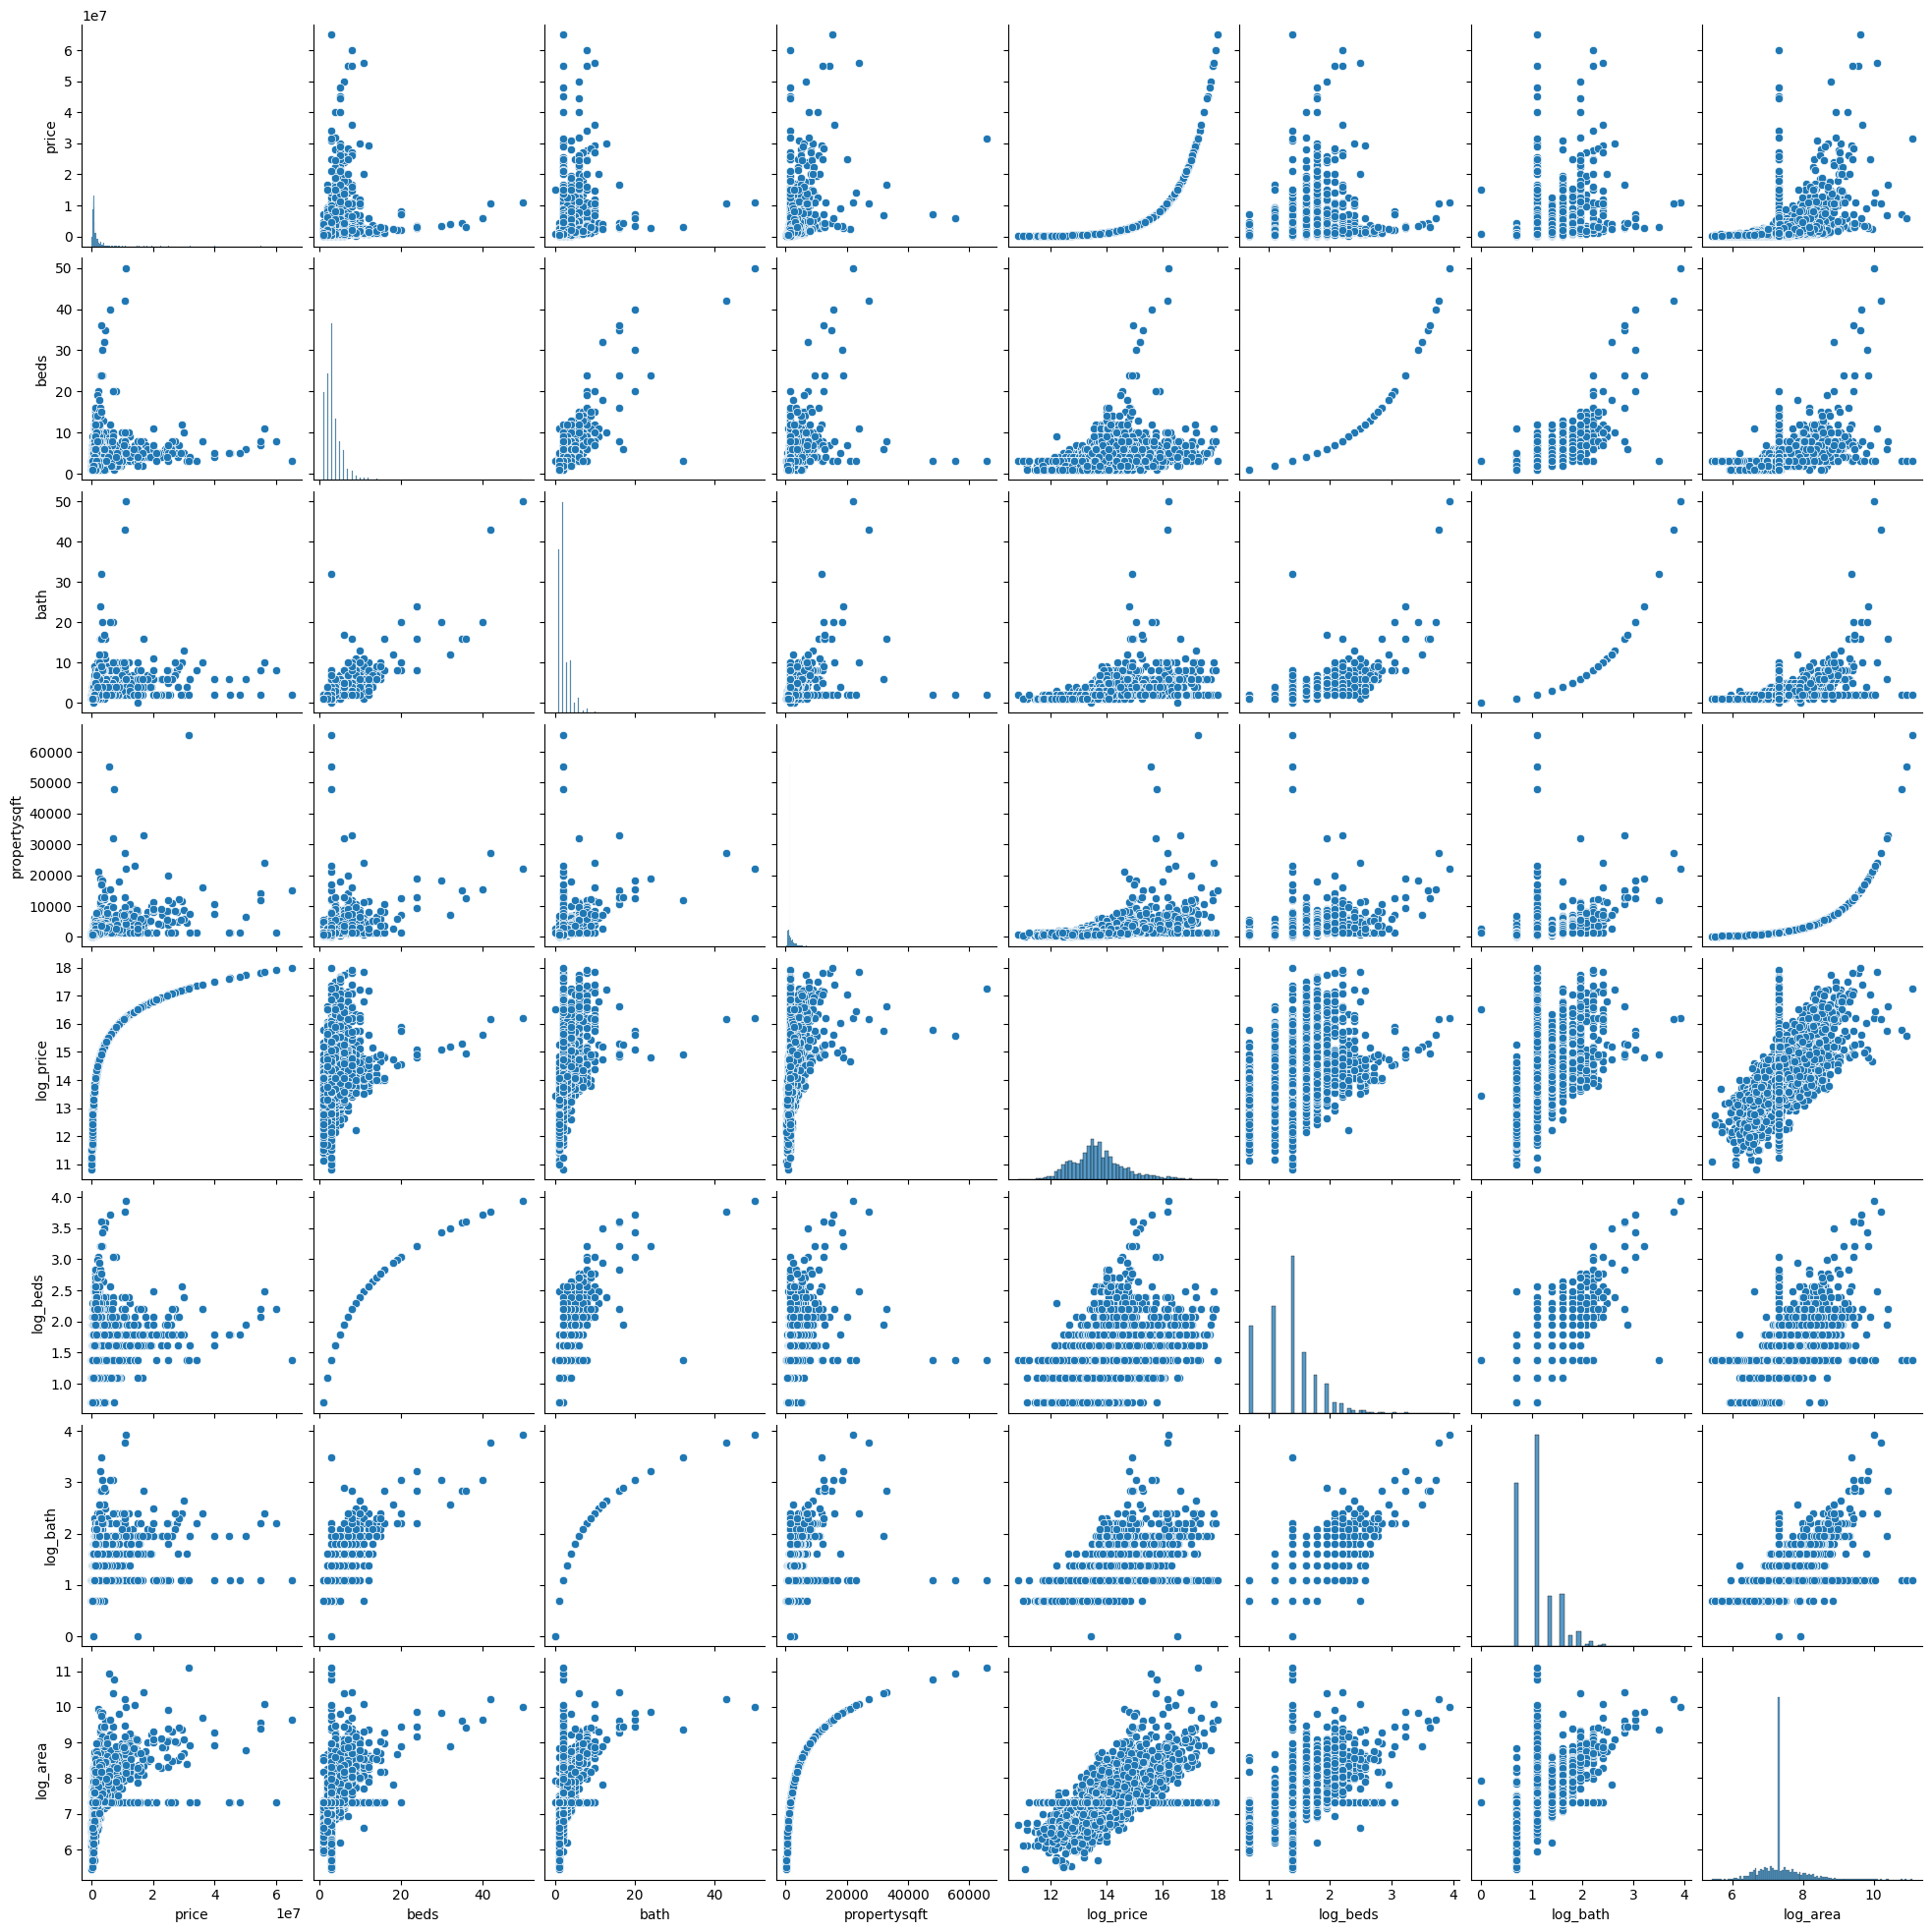

In [209]:
sns.pairplot(df[numerical_columns])

## Spatial distribution

<Axes: xlabel='longitude', ylabel='latitude'>

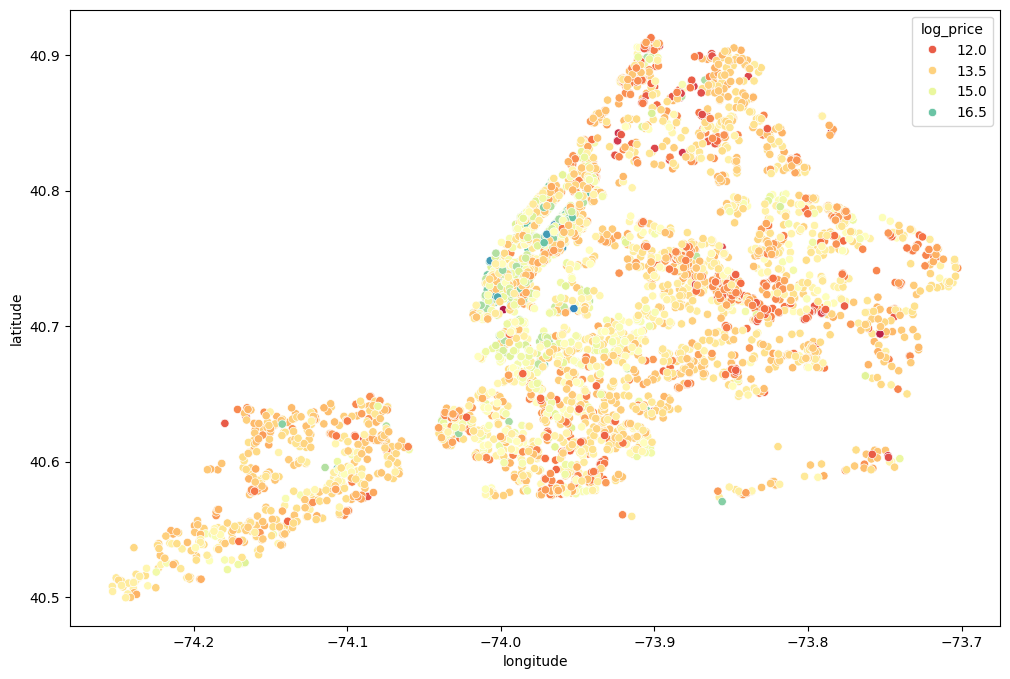

In [211]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="log_price", data=df, palette="Spectral")

<Axes: xlabel='longitude', ylabel='latitude'>

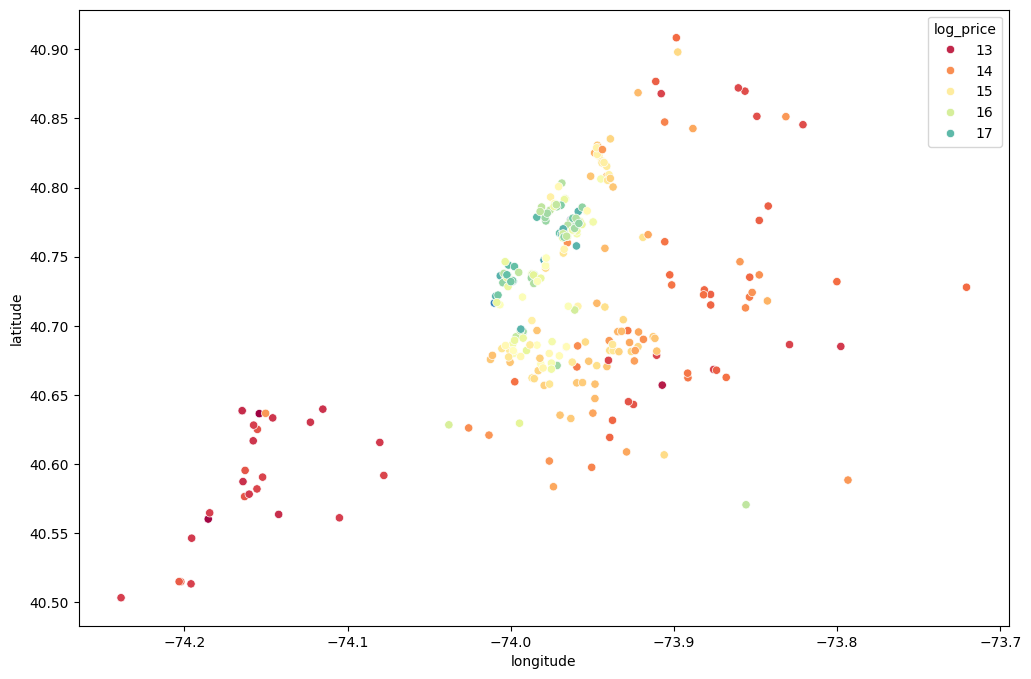

In [214]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="log_price", data=df[df.type=='Townhouse for sale'], palette="Spectral")

<Axes: xlabel='longitude', ylabel='latitude'>

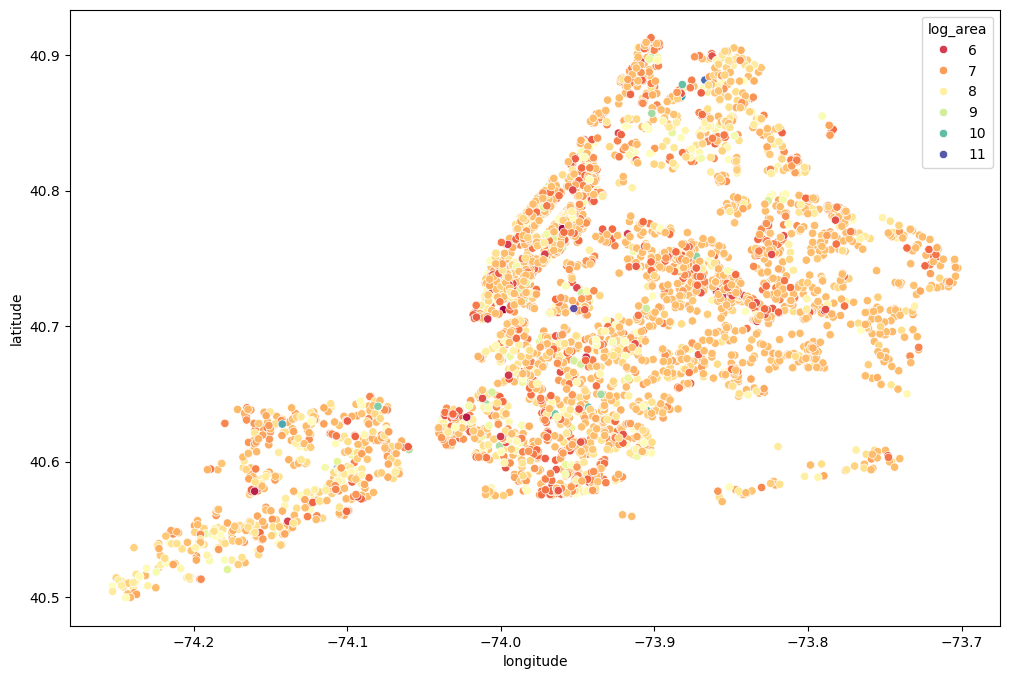

In [215]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="log_area", data=df, palette="Spectral")

<Axes: xlabel='longitude', ylabel='latitude'>

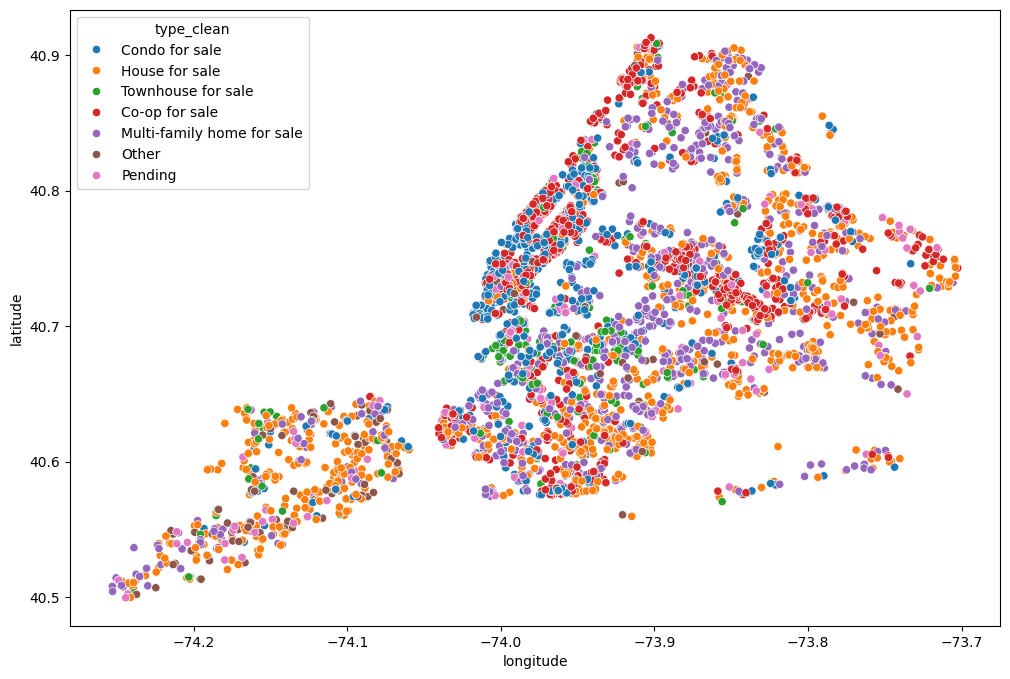

In [218]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="type_clean", data=df)

<Axes: xlabel='longitude', ylabel='latitude'>

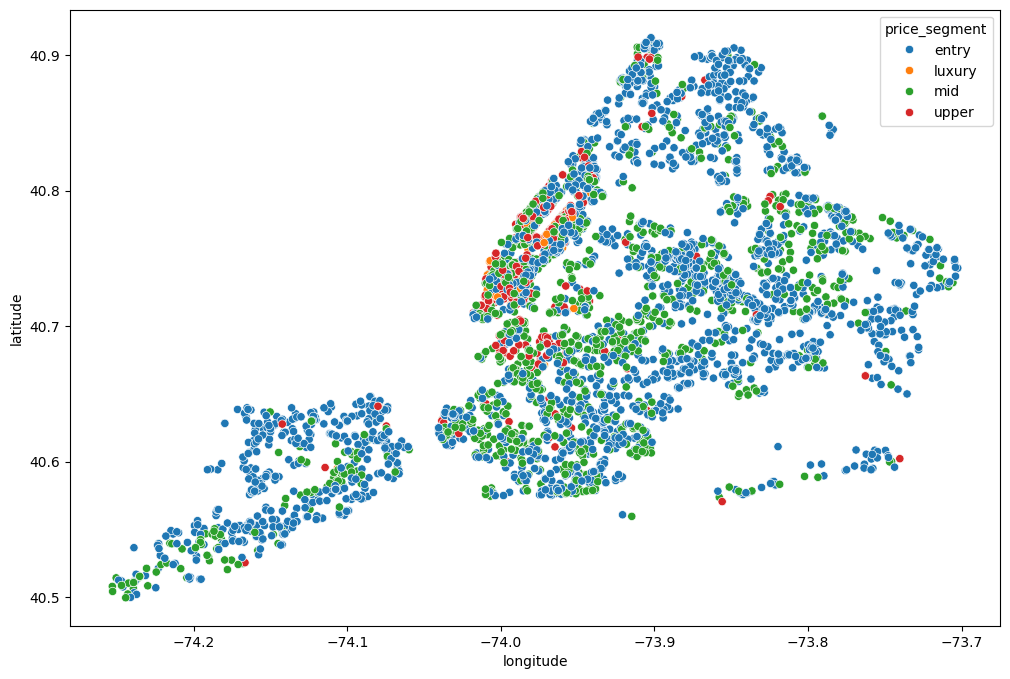

In [220]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="price_segment", data=df)

## Building basiline regression on original dataset

In [222]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

In [223]:
parameter_columns = ['beds', 'bath', 'propertysqft']
target_column = ['price']

In [252]:
def run_regression(df, feature_columns, target_column='price', cv_folds=5):
    X = df[feature_columns]
    y = df[target_column]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print('MAE: ', mae)
    print('R2: ', r2)
    scores = cross_val_score(model, X, y, cv=cv_folds, scoring='r2')
    print(f"Cross-validated R²: {scores.mean():.3f}")
    plt.scatter(y_test, y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
    plt.xlabel('Actual price')
    plt.ylabel('Predicted price')
    plt.title('Actual vs Predicted')
    plt.show()
    print(model.coef_)

MAE:  1446041.864565475
R2:  0.11111155927349747
Cross-validated R²: 0.216


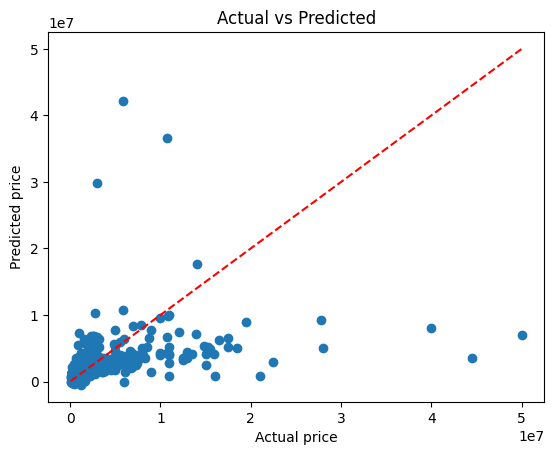

[-318153.01456693  687879.93497455     756.69855659]


In [253]:
run_regression(df, parameter_columns)

In [236]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs Predicted')
plt.show()

NameError: name 'y_test' is not defined

## Building baseline regression on log dataset

In [239]:
parameter_columns_log = ['log_beds', 'log_bath', 'log_area']
target_column = ['price']

MAE:  1669929.6087195377
R2:  0.2488138635270536
Cross-validated R²: 0.223


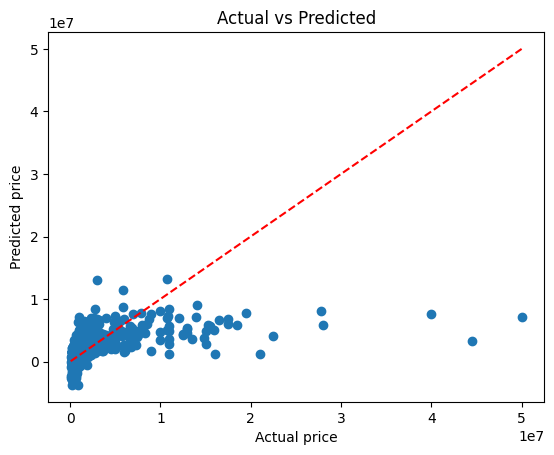

In [240]:
run_regression(df, parameter_columns_log)

In [261]:
df.columns

Index(['type', 'price', 'beds', 'bath', 'propertysqft', 'latitude',
       'longitude', 'is_upper', 'is_mid', 'price_segment', 'log_price',
       'type_clean', 'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds', 'log_bath',
       'area_missing', 'log_area', 'zip', 'borough', 'borough_Manhattan',
       'borough_Brooklyn', 'borough_Queens', 'is_luxury'],
      dtype='object')

In [242]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4582 entries, 0 to 4581
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   type                             4582 non-null   object 
 1   price                            4582 non-null   int64  
 2   beds                             4582 non-null   int64  
 3   bath                             4582 non-null   int64  
 4   propertysqft                     4582 non-null   float64
 5   latitude                         4582 non-null   float64
 6   longitude                        4582 non-null   float64
 7   is_upper                         4582 non-null   int64  
 8   is_mid                           4582 non-null   int64  
 9   price_segment                    4582 non-null   object 
 10  log_price                        4582 non-null   float64
 11  type_clean                       4582 non-null   object 
 12  type_Condo for sale 

## Regression on all non spatial data

In [262]:
all_non_spatial_features = ['is_upper', 'is_mid', 
       'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds', 'log_bath',
       'area_missing', 'log_area', 'is_luxury']

MAE:  683360.037012108
R2:  0.7663371307421669
Cross-validated R²: 0.790


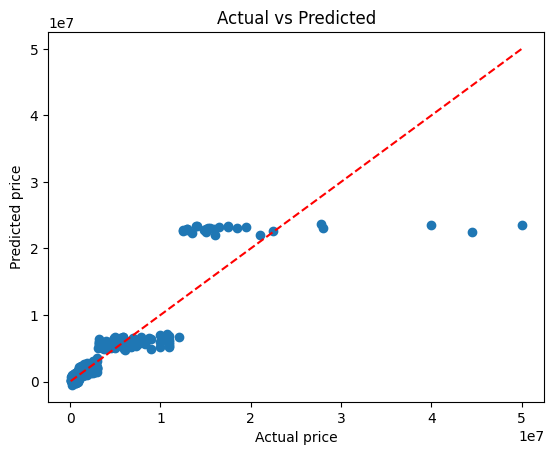

[ 4210102.31634706   728091.11201926   130640.44998244  -200579.86248384
  -504560.91982799  -248558.7313168   -182156.46567385    74206.13077339
  -706833.93934046    87105.834939     540863.5391468    -38661.10225988
   578234.9030896  16881281.70299176]


In [263]:
run_regression(df, all_non_spatial_features)

In [266]:
all_features = ['is_upper', 'is_mid',
       'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds', 'log_bath',
       'area_missing', 'log_area', 'borough_Manhattan',
       'borough_Brooklyn', 'borough_Queens', 'is_luxury']

MAE:  677517.7176225685
R2:  0.7657676220610328
Cross-validated R²: 0.791


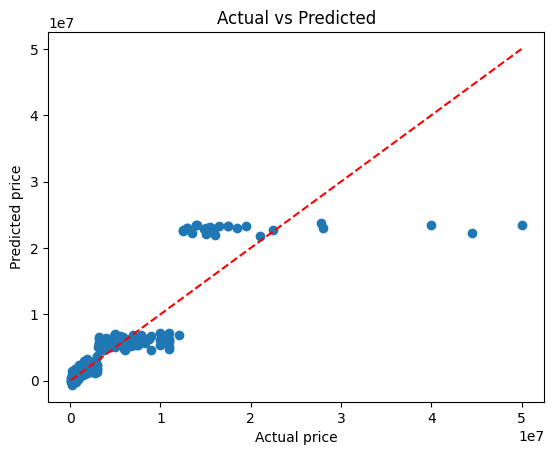

[ 3.86722513e+06  5.64642426e+05  1.33716900e+05 -2.98811626e+03
 -2.91457536e+05 -8.55495237e+04 -8.29807173e+04  1.81162282e+05
 -7.26338173e+05  1.00013255e+05  5.67900854e+05 -1.09174613e+05
  5.91897362e+05  6.57444274e+05  2.55734818e+05  1.76565030e+05
  1.67698682e+07]


In [267]:
run_regression(df, all_features)

In [269]:
df.columns

Index(['type', 'price', 'beds', 'bath', 'propertysqft', 'latitude',
       'longitude', 'is_upper', 'is_mid', 'price_segment', 'log_price',
       'type_clean', 'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds', 'log_bath',
       'area_missing', 'log_area', 'zip', 'borough', 'borough_Manhattan',
       'borough_Brooklyn', 'borough_Queens', 'is_luxury'],
      dtype='object')

In [270]:
all_non_log_features = ['beds', 'bath', 'propertysqft', 
       'is_upper', 'is_mid', 
       'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds', 'log_bath',
       'area_missing', 'log_area', 'borough_Manhattan',
       'borough_Brooklyn', 'borough_Queens', 'is_luxury']

MAE:  660415.1562789277
R2:  0.7639031572634171
Cross-validated R²: 0.795


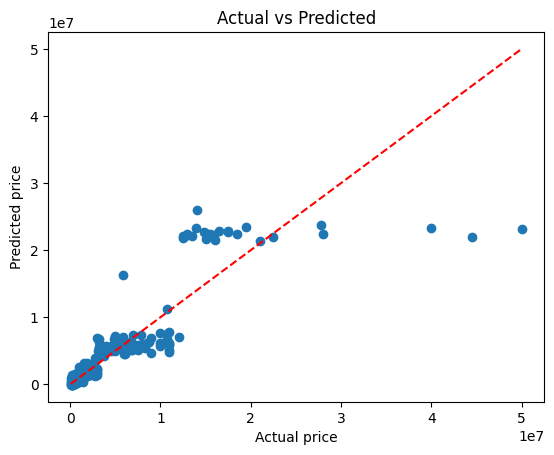

[-9.34388966e+04  9.67184122e+04  2.33556498e+02  3.82801729e+06
  6.48269386e+05  1.48489489e+05  5.49650096e+04 -2.67444590e+05
 -5.23106781e+04 -4.38846772e+04  2.46620326e+05 -9.90101143e+05
  5.80556479e+05  2.93448009e+05  1.26729179e+04 -1.14815529e+05
  6.79551678e+05  2.27297285e+05  1.62931210e+05  1.62559393e+07]


In [271]:
run_regression(df, all_non_log_features)

MAE:  0.2697121952802336
R2:  0.8825501359096255
Cross-validated R²: 0.873


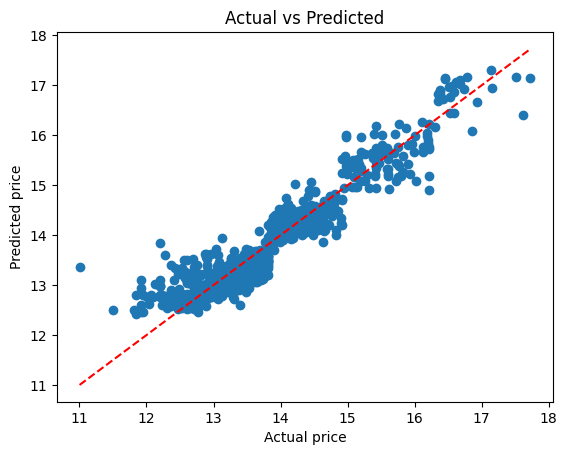

[ 1.57348928  0.72527717  0.38229341  0.45145239  0.33708765  0.29106559
  0.25949542  0.35586239 -0.48997282  0.05043795  0.38090213 -0.00933028
  0.23004558  0.58221809  0.24569828  0.13537179  1.09652134]


In [273]:
run_regression(df, all_features, target_column='log_price')

In [314]:
all_features_without_price_flags = [
       'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds', 'log_bath',
       'area_missing', 'log_area', 'borough_Manhattan',
       'borough_Brooklyn', 'borough_Queens']

MAE:  1560379.0433904117
R2:  0.3827027392621426
Cross-validated R²: 0.349


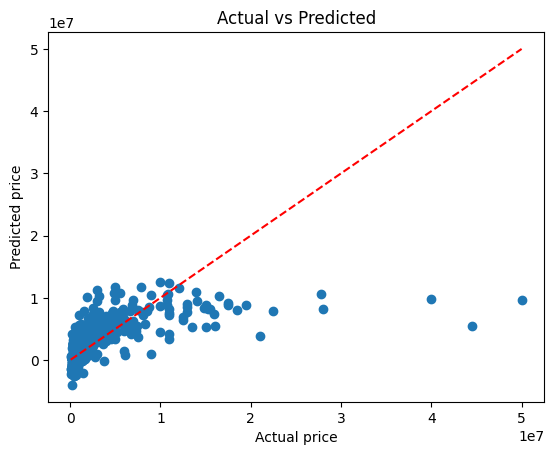

[  474680.65455211  -478303.7244891  -1582451.60172841  -550876.43493889
  -524986.97188907  1745970.99032532 -3940875.08853344   541844.23062894
  2009734.72338625  -152619.33881072  2297018.8524683   2692770.66048107
   530010.35736119   466159.3157771 ]


In [315]:
run_regression(df, all_features_without_price_flags)

## Try predict segments separenly

In [308]:
df.columns

Index(['type', 'price', 'beds', 'bath', 'propertysqft', 'latitude',
       'longitude', 'is_upper', 'is_mid', 'price_segment', 'log_price',
       'type_clean', 'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds', 'log_bath',
       'area_missing', 'log_area', 'zip', 'borough', 'borough_Manhattan',
       'borough_Brooklyn', 'borough_Queens', 'is_luxury'],
      dtype='object')

In [324]:
df_entry = df[df['price_segment'] == 'entry']

MAE:  124358.55595685962
R2:  0.5620860322136144
Cross-validated R²: 0.552


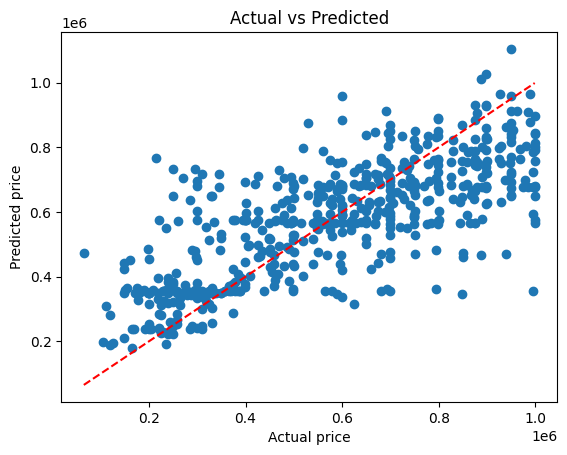

[ 1.59782897e+05  2.05557553e+05  2.40906471e+05  1.25154657e+05
  1.21016606e+05  1.89534620e+05  1.45519152e-10  1.30708015e+04
  2.74217261e+05 -9.09372444e+04  1.69539891e+05  3.28113859e+05
  1.19640702e+05  1.13057077e+05]


In [325]:
run_regression(df_entry, all_features_without_price_flags)

In [326]:
df_mid = df[df['price_segment'] == 'mid']

MAE:  378478.243723415
R2:  0.29527990347920685
Cross-validated R²: 0.234


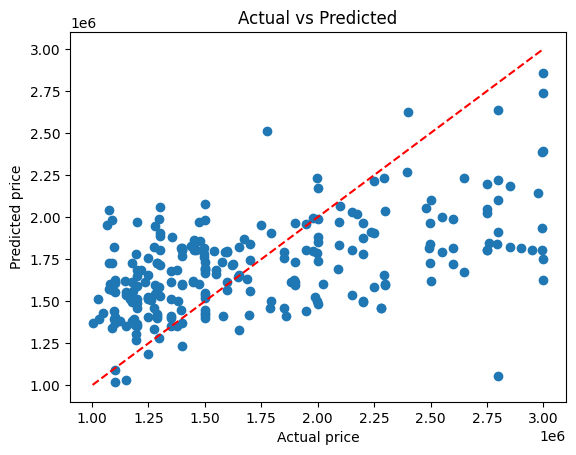

[ 236985.13424901  -31849.87116228 -214881.15172555  147777.21367252
 -128264.18927133   79278.25729857 -111172.75172933   62099.19294348
  231443.04314744  106249.60454175  473003.07374964  604971.76897234
  425091.32521458  256595.57833853]


In [327]:
run_regression(df_mid, all_features_without_price_flags)

In [328]:
df_upper = df[df['price'] >3000000]

MAE:  5045877.294118161
R2:  0.3360924260949453
Cross-validated R²: 0.174


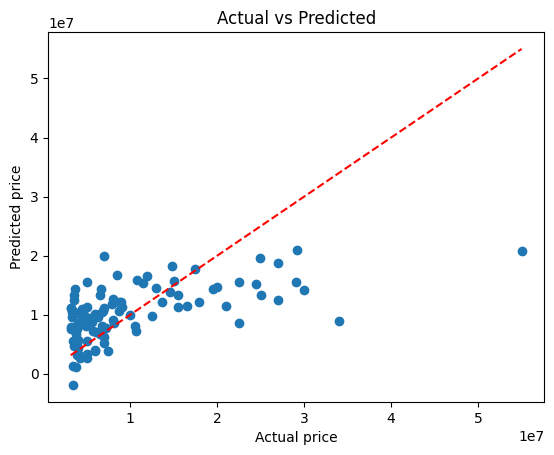

[  4417873.19693157   2401500.00685185  -1869033.07628277
    648757.72717381    720436.19586319    675981.52030935
 -12606360.53318832   2811788.04630971    417056.93492588
  11596278.04774546   8599084.22987175   9838317.35226544
   5837799.49181587   2161241.15230414]


In [329]:
run_regression(df_upper, all_features_without_price_flags)

In [330]:
## Check fearure importance with Lasso

In [342]:
from sklearn.linear_model import Lasso


X = df[all_features]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Lasso(alpha=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MAE: ', mae)
print('R2: ', r2)
print(model.coef_)

MAE:  670058.5708664808
R2:  0.7676917385894615
[ 3.90848993e+06  5.59795633e+05  1.22724754e+05  3.01963872e+03
 -2.16748688e+05 -0.00000000e+00 -0.00000000e+00  1.71943860e+05
 -0.00000000e+00  1.90112180e+04  5.26182546e+05 -7.52007156e+04
  5.97145764e+05  5.77287607e+05  1.61643877e+05  7.44595530e+04
  1.66074286e+07]


In [334]:
all_features

['is_upper',
 'is_mid',
 'type_Condo for sale',
 'type_House for sale',
 'type_Multi-family home for sale',
 'type_Other',
 'type_Pending',
 'type_Townhouse for sale',
 'is_high_beds',
 'log_beds',
 'log_bath',
 'area_missing',
 'log_area',
 'borough_Manhattan',
 'borough_Brooklyn',
 'borough_Queens',
 'is_luxury']

In [344]:
corrected_features = ['is_upper',
 'is_mid',
 'type_Condo for sale',
 'type_House for sale',
 'type_Multi-family home for sale',
 #'type_Other',
 #'type_Pending',
 'type_Townhouse for sale',
 #'is_high_beds',
 'log_beds',
 'log_bath',
 'area_missing',
 'log_area',
 'borough_Manhattan',
 'borough_Brooklyn',
 'borough_Queens',
 'is_luxury']

MAE:  675859.5175875897
R2:  0.7651387366602
Cross-validated R²: 0.791


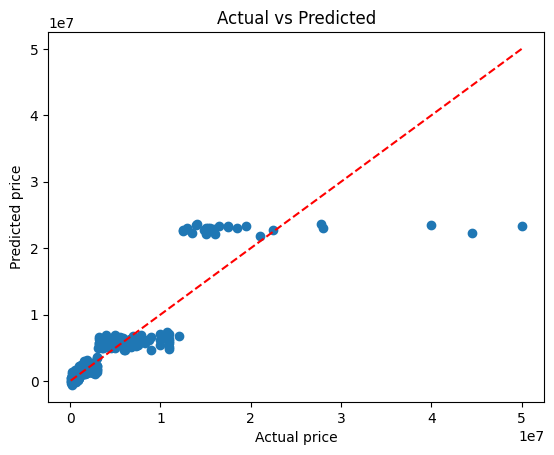

[ 3895368.09613846   578693.36386975   155384.4925156     53503.79316537
  -236477.00635059   242565.31489761    44170.36649188   524357.85139601
  -107495.48494233   583472.89442194   664655.22794692   250193.7333644
   179758.13357278 16798519.00610875]


In [345]:
run_regression(df, corrected_features)

## Add is_upper and area_missing

In [ ]:
parameter_columns_log = ['log_beds', 'log1_bath', 'log_area', 'is_upper', 'area_missing']
target_column = ['price']

In [ ]:
X = df[parameter_columns_log]
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MAE: ', mae)
print('R2: ', r2)

In [ ]:
# Perform cross-validation
scores = cross_val_score(model, X, y, cv=10, scoring='r2')
print(f"Cross-validated R²: {scores.mean():.3f}")

In [ ]:
model.coef_

In [ ]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs Predicted')
plt.show()

## Building baseline regression on limited dataset

In [ ]:
df_lower = df[df.price<limiter]

In [ ]:
parameter_columns = ['beds', 'bath', 'propertysqft', 'area_missing']
target_column = ['price']

In [ ]:
X = df_lower[parameter_columns]
y = df_lower[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MAE: ', mae)
print('R2: ', r2)

In [ ]:
# Perform cross-validation
scores = cross_val_score(model, X, y, cv=10, scoring='r2')
print(f"Cross-validated R²: {scores.mean():.3f}")

In [ ]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs Predicted')
plt.show()

## _TODO: Посмотреть что за точки выбросило вверх, из за этого всю регрессию занизило_

In [ ]:
limiter

In [ ]:
y_pred_series = pd.Series(y_pred.flatten(), index=y_test.index)

In [ ]:
#results = pd.DataFrame({'True Value': y_test, 'Predicted Value': y_pred_series})


In [ ]:
type(y_pred_series)

In [ ]:
y_pred_series.name = 'predicted'

In [ ]:
y_pred_series

In [ ]:
type(y_test)

In [ ]:
y_test.head()

In [ ]:
y_test.rename(columns={'price': 'actual_price'}, inplace=True)

In [ ]:
y_test.head()

In [ ]:
results = y_test.merge(y_pred_series, left_index=True, right_index=True)

In [ ]:
results.predicted.astype(int)

In [ ]:
results.predicted = results.predicted.astype(int)

In [ ]:
results

In [ ]:
results.sort_values(by=['predicted'], ascending=False, inplace=True)

In [ ]:
results

In [ ]:
df.iloc[598]

In [ ]:
df.iloc[598][parameter_columns]

In [ ]:
a_test = pd.DataFrame(df.iloc[598][parameter_columns]).transpose()

In [ ]:
a_test.beds = a_test.bath * 1.5

In [ ]:
model.predict(a_test)

In [ ]:
df.iloc[4054]

In [ ]:
df.bath.describe()

In [ ]:
df['beds_to_bath'] = np.where(df.bath==0, 0, df.beds/df.bath)

In [ ]:
df.beds_to_bath.describe()

In [ ]:
plt.figure(figsize=(12, 8))
sns.boxplot(df, y='beds_to_bath', hue='type')

### Regression for upper segment

In [ ]:
df_upper = df[df.price>=limiter]

In [ ]:
parameter_columns = ['beds', 'bath', 'propertysqft']
target_column = ['price']

In [ ]:
X = df_upper[parameter_columns_log]
y = df_upper[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MAE: ', mae)
print('R2: ', r2)

In [ ]:
# Perform cross-validation
scores = cross_val_score(model, X, y, cv=10, scoring='r2')
print(f"Cross-validated R²: {scores.mean():.3f}")

In [ ]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs Predicted')
plt.show()

In [ ]:
parameter_columns_log

In [ ]:
X = df_upper[parameter_columns_log]
y = df_upper[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MAE: ', mae)
print('R2: ', r2)

In [ ]:
# Perform cross-validation
scores = cross_val_score(model, X, y, cv=10, scoring='r2')
print(f"Cross-validated R²: {scores.mean():.3f}")

_Log trimmed dataset perform best_

In [ ]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs Predicted')
plt.show()

# Ridge and Polynomial excluded for now. Go to feature engineering

## Try Ridge

In [ ]:
from sklearn.linear_model import RidgeCV

# Try a range of alpha values
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

# Use RidgeCV to find the best alpha
model = RidgeCV(alphas=alphas, cv=5)
model.fit(X, y)

# Best alpha value
print(f"Best alpha: {model.alpha_}")

In [ ]:
from sklearn.linear_model import Ridge

#X = df[['log_beds', 'log1_bath', 'log_area']]
X = df_lower[['log_beds', 'log1_bath', 'log_area', 'type']+ list(type_encoded_df.iloc[:,1:].columns)]  # Include 'type'
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Ridge(alpha=10.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# y_test_original = np.exp(y_test)
#3y_pred_original = np.exp(y_pred)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MAE: ', mae)
print('R2: ', r2)

In [ ]:
# Perform cross-validation
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"Cross-validated R²: {scores.mean():.2f}")

In [ ]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs Predicted')
plt.show()

## Try polinomial

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Features (logged)
#X = df[['log_beds', 'log1_bath', 'log_area']]
X = df_lower[['log_beds', 'log1_bath', 'log_area', 'type']+ list(type_encoded_df.iloc[:,1:].columns)]  # Include 'type'

# Target (unlogged)
y = df['price']

# Generate polynomial features (degree=2 includes squared terms and interaction terms)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Check the shape of the transformed data
print(X_poly.shape)  # Should have more columns than the original features

In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate MAE and R²
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('MAE: ', mae)
print('R²: ', r2)

In [ ]:
scores = cross_val_score(model, X_poly, y, cv=5, scoring='r2')
print(f"Cross-validated R²: {scores.mean():.2f}")

In [ ]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs Predicted')
plt.show()

# TASK 3: FEATURE ENGINEERING

## OHE for type

In [ ]:
df_backup3 = df.copy()

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Initialize the encoder
encoder = OneHotEncoder(sparse_output=False) 

# Fit and transform the 'type' column
type_encoded = encoder.fit_transform(df[['type']])

# Convert the result to a DataFrame
type_encoded_df = pd.DataFrame(type_encoded, columns=encoder.get_feature_names_out(['type']))

# Standartize column names
type_encoded_df.columns = type_encoded_df.columns.str.lower().str.replace(' ', '_')

# Concatenate with the original DataFrame
df = pd.concat([df, type_encoded_df.iloc[:,1:]], axis=1)

In [ ]:
df.isna().sum()

In [ ]:
limiter

In [ ]:
df_lower = df[df.price<limiter]

In [ ]:
df_lower.shape

In [ ]:
df_lower.shape[0]/original_length

In [ ]:
from sklearn.preprocessing import TargetEncoder
# Add 'type' to X temporarily
X = df_lower[['log_beds', 'log1_bath', 'log_area', 'type']+ list(type_encoded_df.iloc[:,1:].columns)]  # Include 'type'
y = df_lower['price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the TargetEncoder
encoder = TargetEncoder()

# Isolate the 'type' column
type_train = X_train[['type']]  # Use double brackets to keep it as a DataFrame
type_test = X_test[['type']]

# Fit and transform the 'type' column in the training set
type_train_encoded = encoder.fit_transform(type_train, y_train)

# Transform the 'type' column in the test set
type_test_encoded = encoder.transform(type_test)

# Drop the original 'type' column and add the encoded version
X_train_encoded = X_train.drop(columns=['type'])
X_test_encoded = X_test.drop(columns=['type'])

X_train_encoded['type_encoded'] = None
X_test_encoded['type_encoded'] = None

X_train_encoded['type_encoded'] = type_train_encoded
X_test_encoded['type_encoded'] = type_test_encoded

# Now X_train_encoded and X_test_encoded have the 'type' column replaced with its encoded version


In [ ]:
from sklearn.preprocessing import TargetEncoder
# Select features and target 'area_missing', 'log_area',
X = df_lower[['log_beds', 'log1_bath', 'log_area'] + list(type_encoded_df.iloc[:,1:].columns)]
y = df_lower['price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

encoder = TargetEncoder()
X_train_encoded = encoder.fit_transform(X_train, y_train)
# Transform the test set
X_test_encoded = encoder.transform(X_test)

In [ ]:
pd.DataFrame(X_train_encoded).head(10)

In [ ]:
X_train_encoded.shape

In [ ]:
X_train.shape

In [ ]:
type(X_train)

In [ ]:
type(X_train_encoded)

In [ ]:
y_pred.shape

In [ ]:
# Train the model
model = LinearRegression()
model.fit(X_train_encoded, y_train)

# Evaluate the model
y_pred = model.predict(X_test_encoded)
#y_test_original = np.exp(y_test)
#y_pred_original = np.exp(y_pred_log)

mae_original = mean_absolute_error(y_test, y_pred)
r2_original = r2_score(y_test, y_pred)
print(f"MAE in original scale: {mae_original:.2f}")
print(f"R² in original scale: {r2_original:.2f}")

In [ ]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
#y_test_original = np.exp(y_test)
#y_pred_original = np.exp(y_pred_log)

mae_original = mean_absolute_error(y_test, y_pred)
r2_original = r2_score(y_test, y_pred)
print(f"MAE in original scale: {mae_original:.2f}")
print(f"R² in original scale: {r2_original:.2f}")

In [ ]:
# Perform cross-validation
scores = cross_val_score(model, X, y, cv=4, scoring='r2')
print(f"Cross-validated R²: {scores.mean():.2f}")

In [ ]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs Predicted')
plt.show()

## _R2 Baseline after One Hot Encoder is 0.41_

In [ ]:
# Target Encoding (if you want to try it)
from sklearn.preprocessing import TargetEncoder
encoder = TargetEncoder()
df['type_target_encoded'] = encoder.fit_transform(df[['type']], df['price'].values)

In [ ]:
df.type_target_encoded.describe()

In [ ]:
df.type_target_encoded.value_counts()

In [ ]:
df.columns